<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Numerical_Simulation_of_Electron_Hydrodynamic_Refrigeration_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

Preparing the private Python/CUDA environment automatically. The first run may take several minutes.
Automatic dependency setup: 20 s elapsed...
Dependencies verified: 1.5.0 1.26.4 1.15.2 13.6.0
Running the simulation and preparing the figures...
Flow: 272 cells, 498 faces, R=27.548 ohm, continuity=1.56e-14; CPU sparse LU (RCM plus COLAMD), 0.0 s
Conservation, zero-bias, and thermoelectric sign checks passed.
Model: gated graphene hydrodynamic thermoelectric refrigeration.
CUDA verified: NVIDIA L4, free VRAM 21.8 GiB.
Flow: 6,421 cells, 12,624 faces, R=25.748 ohm, continuity=1.46e-13; CPU sparse LU (RCM plus COLAMD), 0.4 s
Thermal benchmark: CPU 0.0226 s, GPU 0.5130 s; selected CPU.
Simulation: 20 s elapsed...
hydro mesh 1: ROI=146.6576 K, cooling=3.3424 K, 100 accepted/0 rejected steps, 13.7 s.
Flow: 12,469 cells, 24,636 faces, R=25.660 ohm, continuity=2.16e-13; CPU sparse LU (RCM plus COLAMD), 0.8 s
Thermal benchmark: CPU 0.0516 s, GPU 0.7347 s; selected CPU.
Simulation: 40 s elapsed

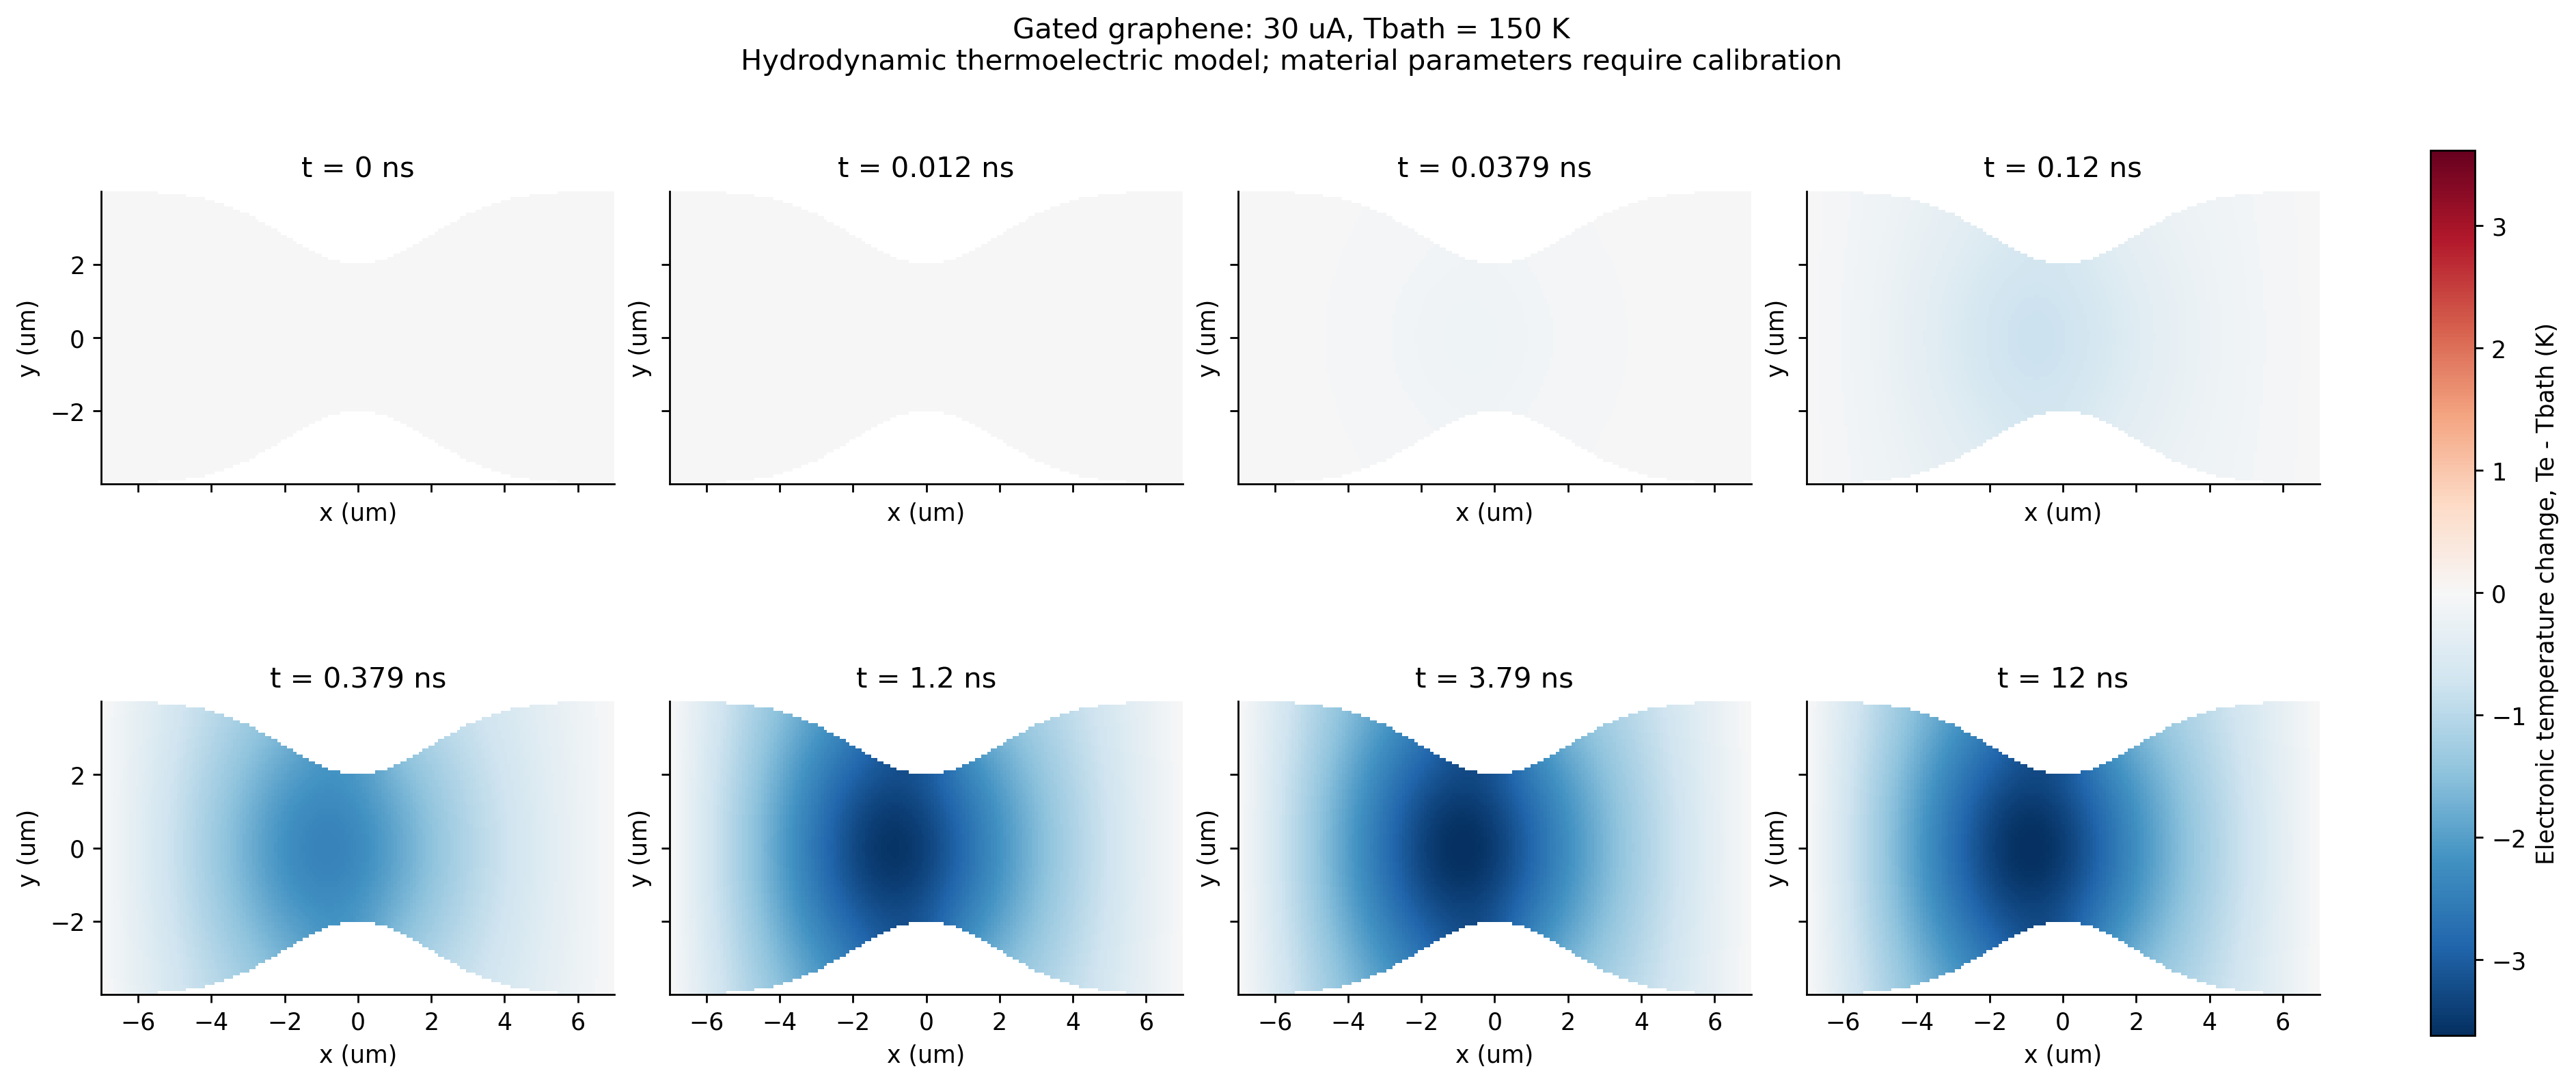

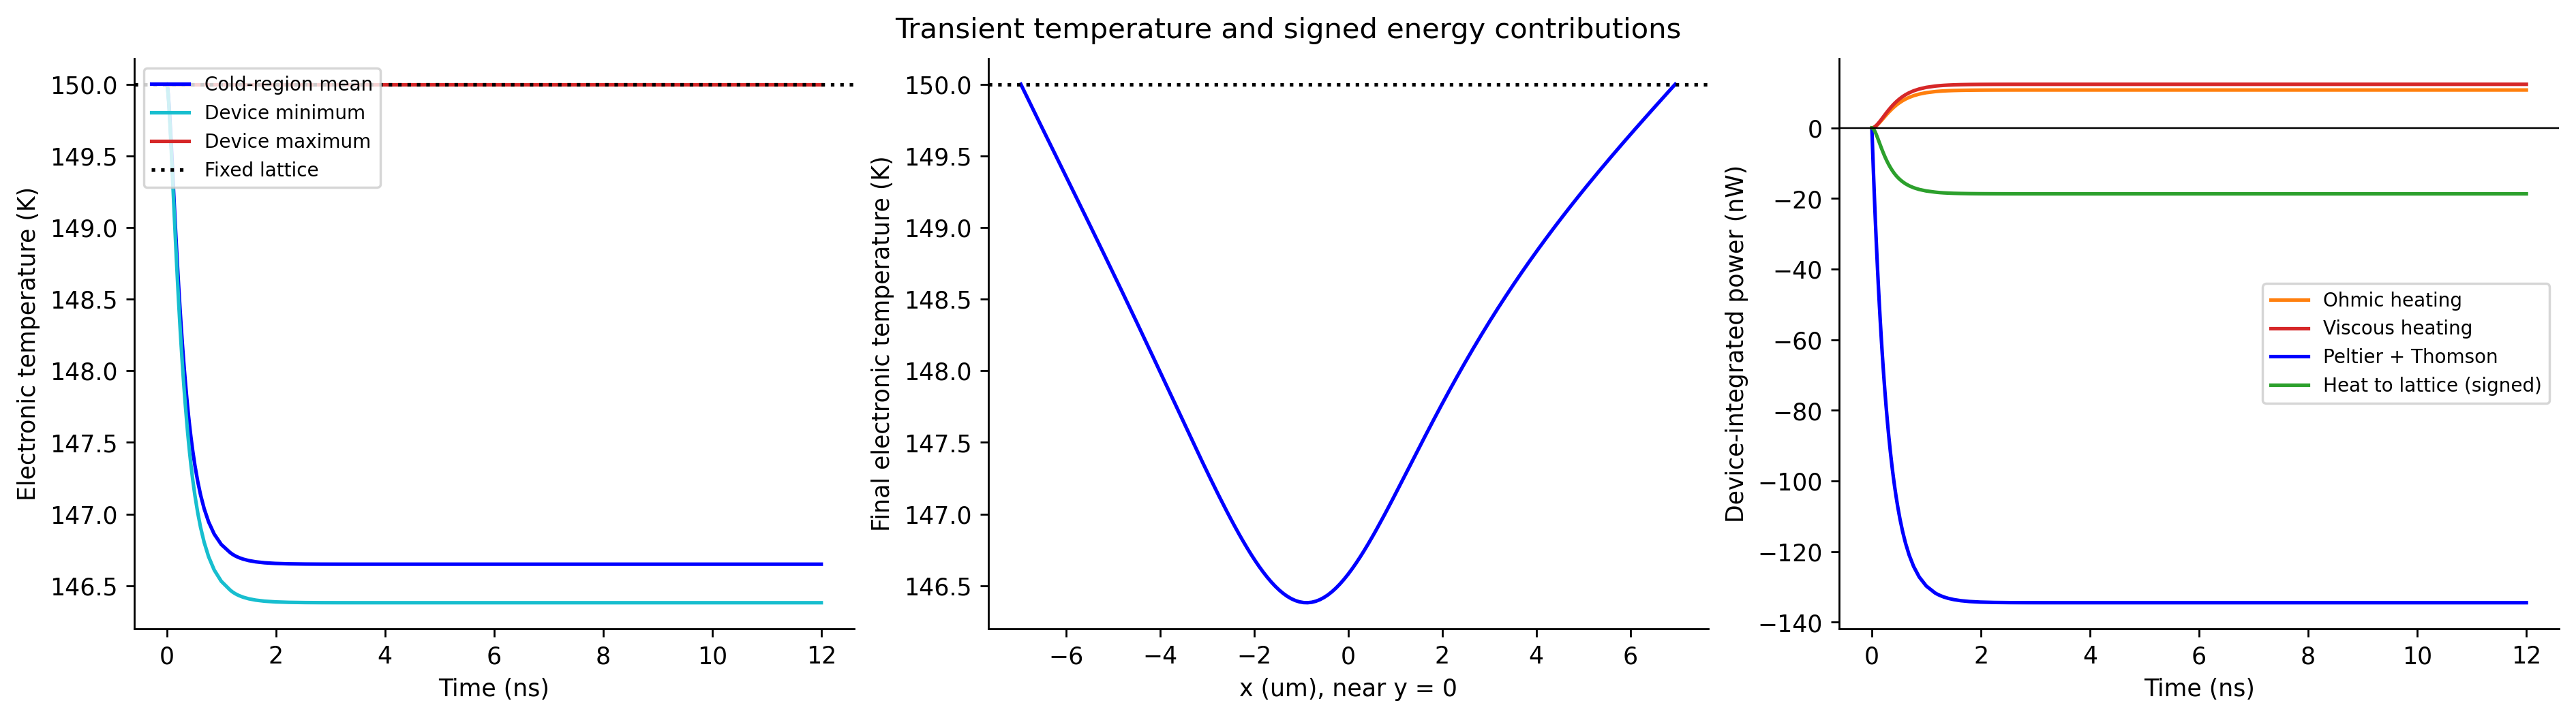

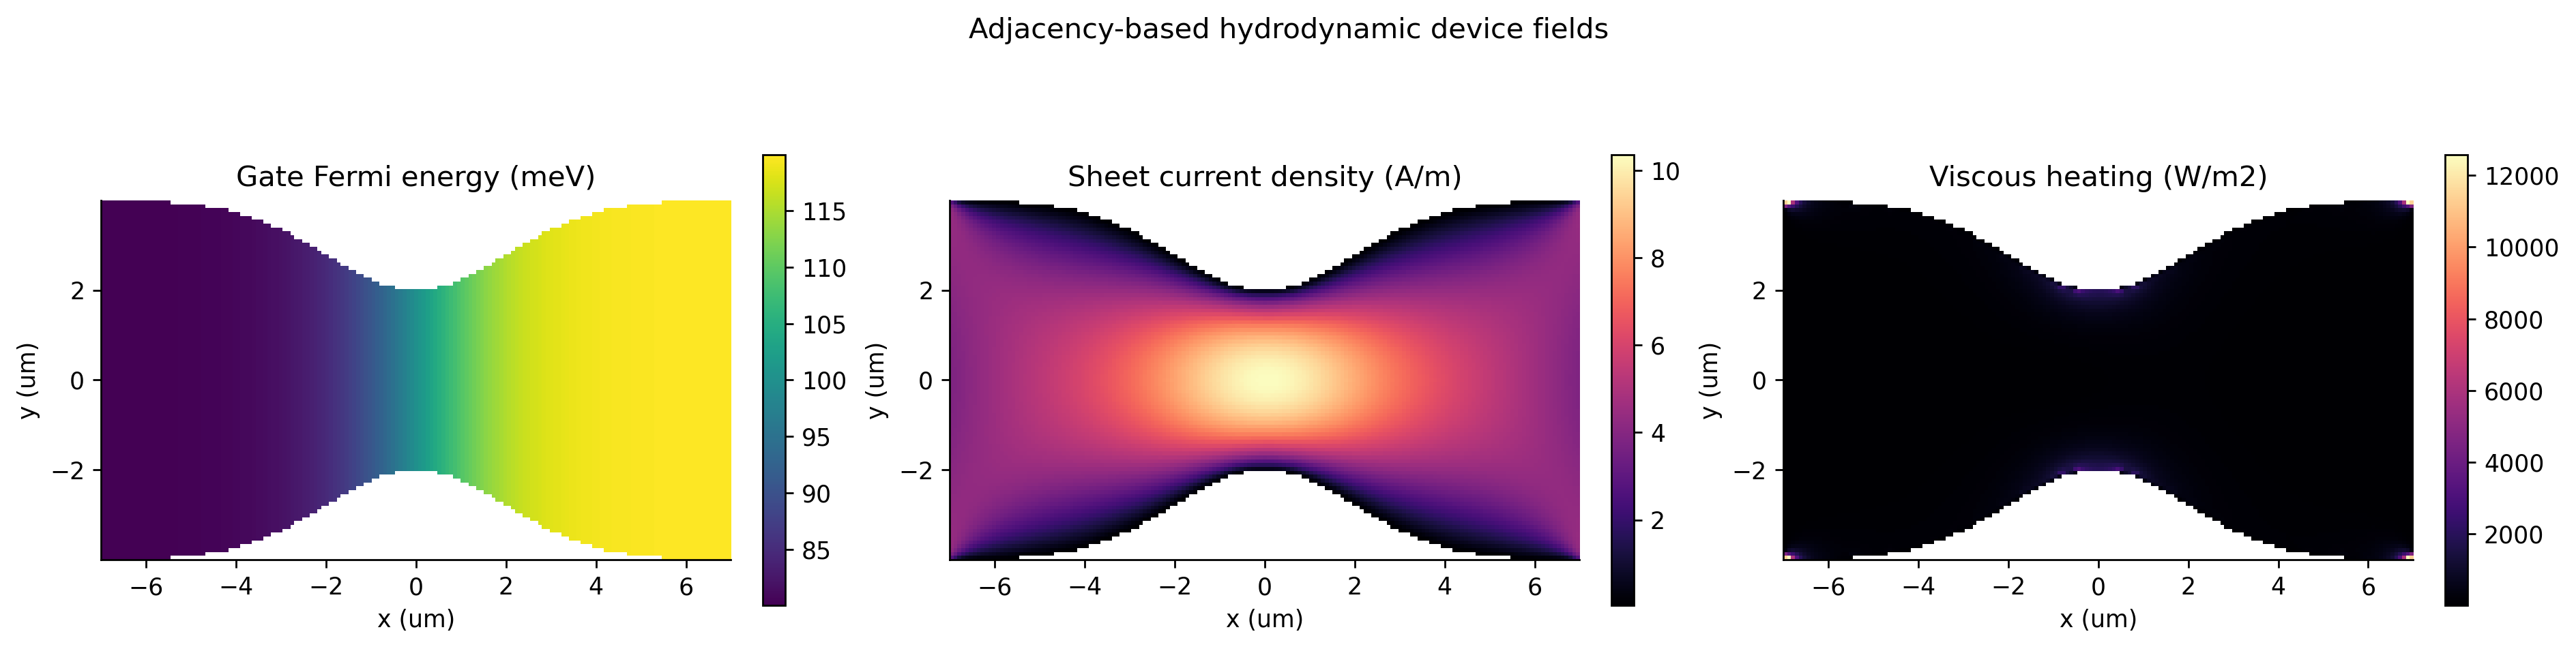

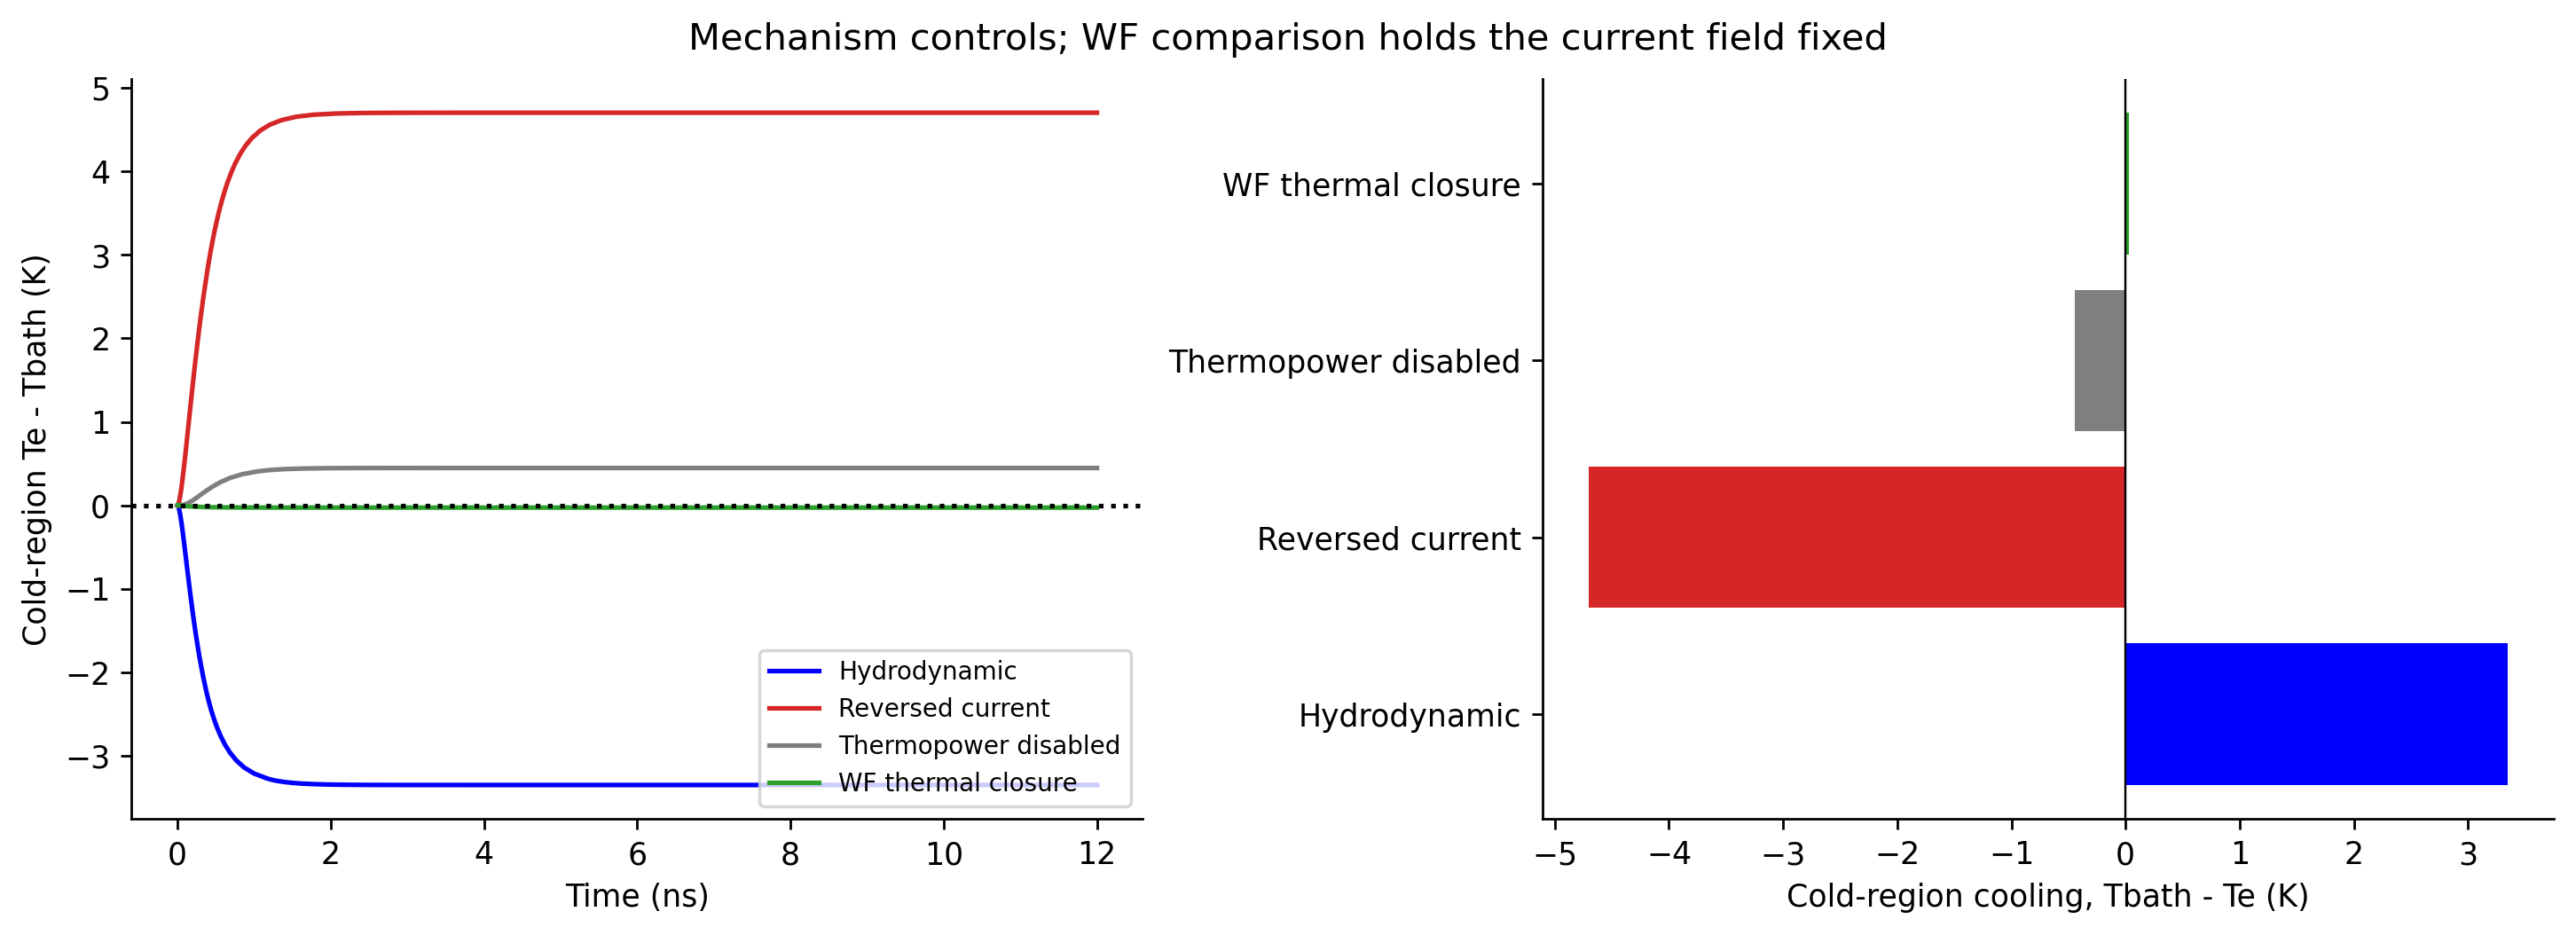

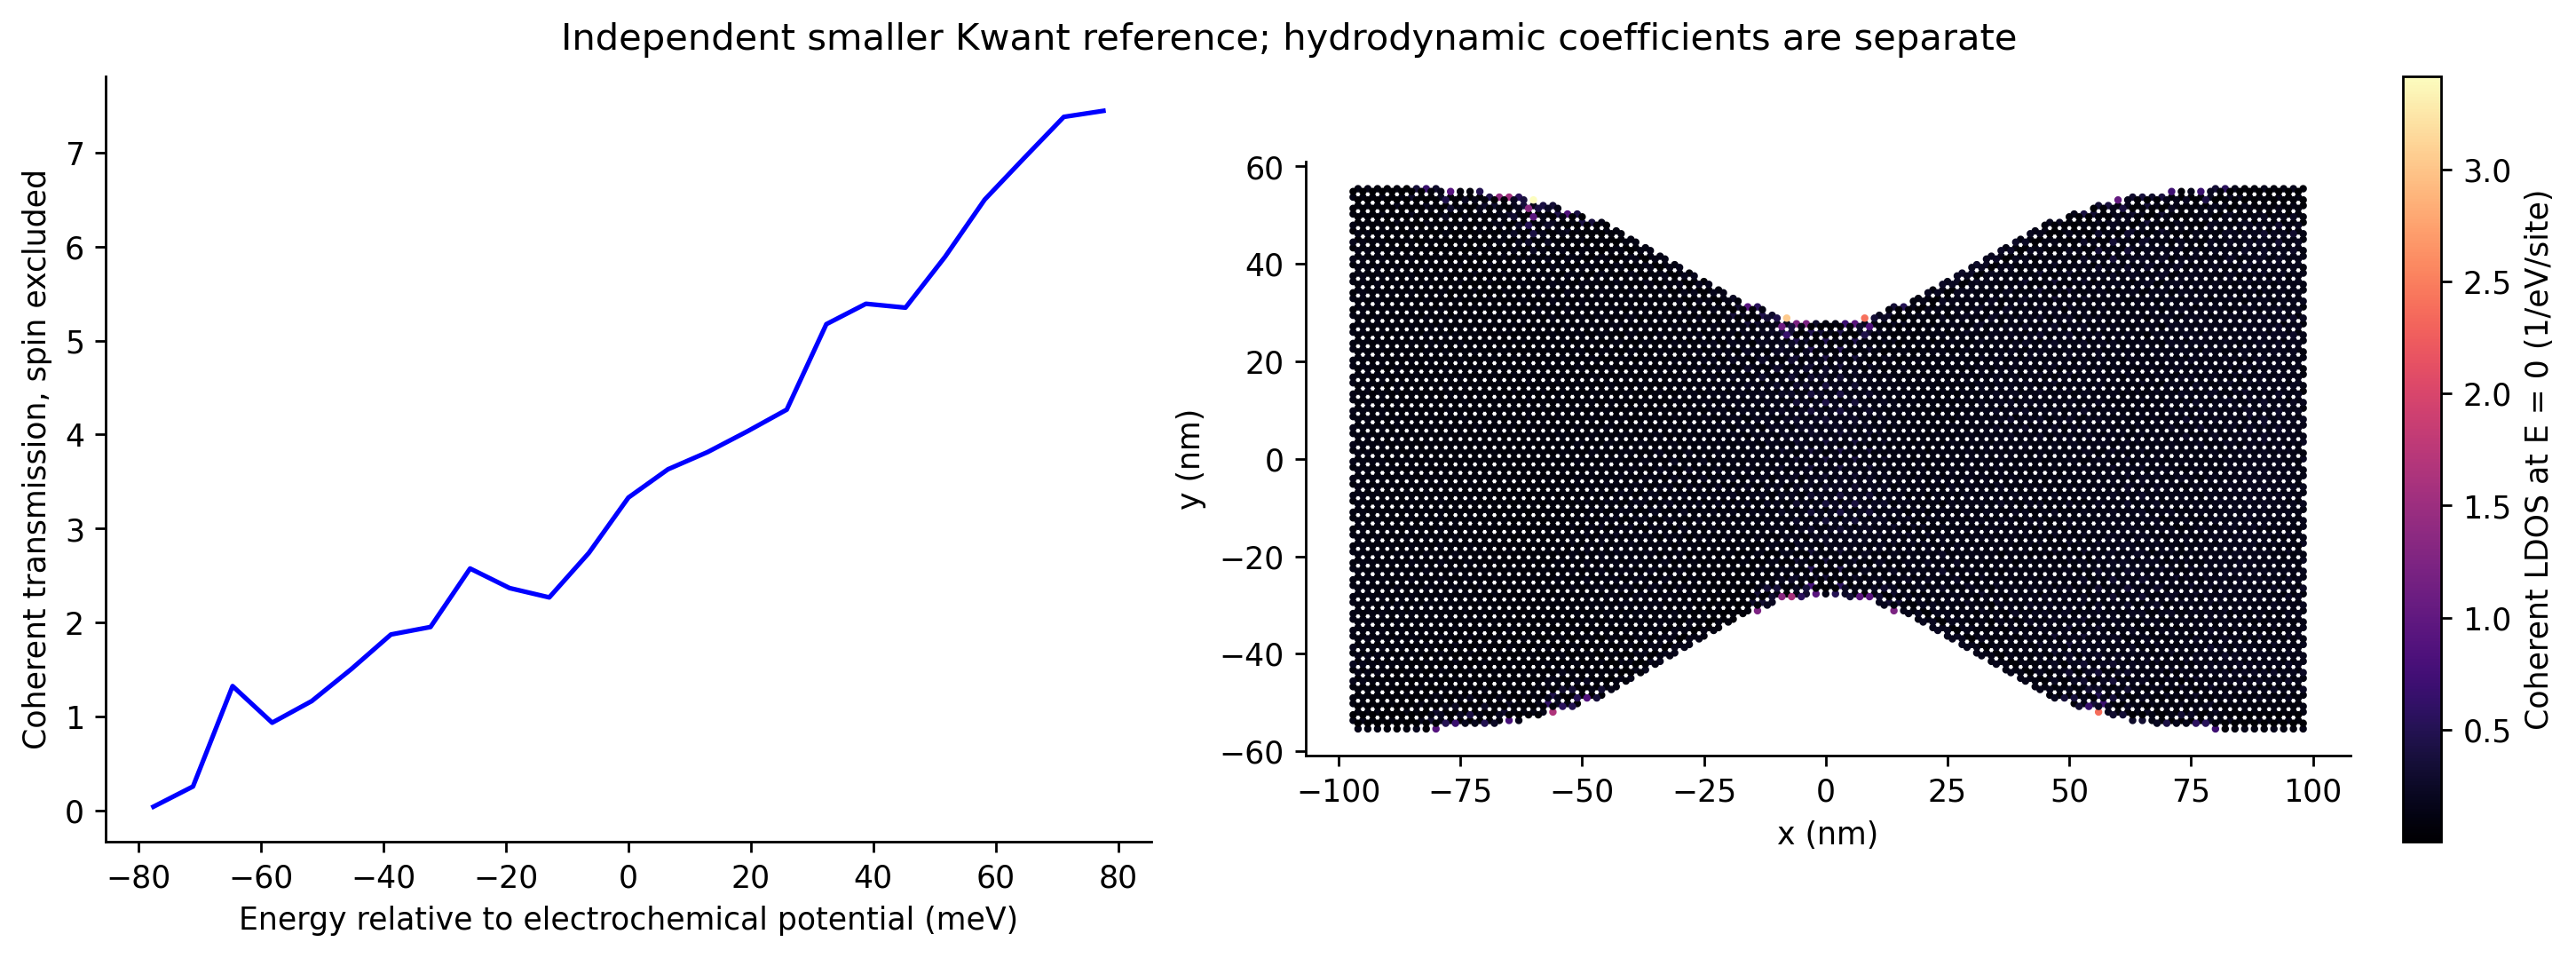

/content/electron_hydrodynamic_results/electron_hydrodynamic_results.zip

In [1]:
"""Simulate a gated graphene hydrodynamic thermoelectric refrigerator.

Edit CONFIG below to adjust the physical and numerical controls. For file
execution, --quick selects a coarse preview, --cpu forces CPU calculations,
and --no-kwant skips the independent coherent-transport reference explicitly.

Physical model
--------------
This is a reduced, single-carrier, degenerate hydrodynamic thermoelectric
model, rather than an ab initio or collision-resolved refrigeration prediction.
An adjacency graph represents finite-volume cells and oriented face currents.
A positive Brinkman dissipation functional determines a charge-conserving
current field, including momentum relaxation, velocity-gradient dissipation,
and no-slip side walls. Uniform end-face current injection is prescribed;
electrically equipotential contacts and their detailed boundary layers are not
resolved. Momentum is quasistatic, with bath-temperature coefficients;
thermoelectric feedback on the 2D current distribution is neglected.
Variable-density velocity-gradient dissipation is a reduced viscous closure,
not a full compressible graphene stress tensor or Navier-Stokes model.

The nonlinear electronic energy equation includes conduction, irreversible
Ohmic and viscous heating, Kelvin-consistent Peltier/Thomson terms, a specified
electron-phonon heat leak, and an optional external thermal load. Electron heat
capacity, thermopower, and suppressed thermal conductivity follow degenerate
graphene approximations. The gates produce a thermopower gradient, so
electrical
work transports heat from the junction to reservoirs; no artificial negative
heat source is prescribed. Electron-electron scattering redistributes energy
and modifies transport coefficients; it is not an energy sink. Both end
reservoirs and the fixed lattice are held at BATH_T_K. Lattice refrigeration,
Joule-Thomson expansion, Dirac-fluid electron-hole transport, microscopic
gold-contact energy filtering, and millikelvin operation are not modeled.

Kwant computes an independent, physically smaller, coherent honeycomb reference
with the same shape ratios and gate chemical potentials. Its coarse lattice and
rescaled hopping preserve the low-energy Fermi velocity, rather than the atomic
graphene lattice spacing. It does not determine
the hydrodynamic coefficients, and its ballistic heat conductance is never used
as a hydrodynamic cooling term. Spin degeneracy is two; valleys are already
included in the honeycomb lattice. Kwant's scattering calculation runs on CPU.
CuPy accelerates repeated thermal sparse solves only when a warm benchmark and
memory estimate favor it. Float64 is used throughout the continuum calculation.

Numerics and interpretation
---------------------------
CSR adjacency operators, resource-limited mesh refinement, CPU sparse LU or
preconditioned Krylov flow solving, benchmarked thermal CPU/GPU selection, and
adaptive time steps manage complexity. Refinement is global, not local AMR.
Two-grid cooling differences are reported; an unmet mesh tolerance is labeled
unconverged. Nonlinear enthalpy integration and energy/current checks reject
inconsistent steps. The script reports whether the chosen parameters produce
cooling, rather than assuming that refrigeration occurs for every current.
All transport and electron-phonon parameters require experimental calibration.

References
----------
[1] Andersen, Smith, and Principi, Phys. Rev. Lett. 122, 166802 (2019).
    https://doi.org/10.1103/PhysRevLett.122.166802
    https://arxiv.org/pdf/1806.09627
    Basis of kappa = L0*sigma*T/(1 + 8*Gamma_ee/(5*Gamma_mr)), doubled
    degenerate hydrodynamic graphene thermopower, and the Thomson heat term.
[2] Vera-Marun et al., Nature Communications 7, 11525 (2016).
    https://doi.org/10.1038/ncomms11525
    Experimental graphene Peltier cooling/heating and Kelvin relation.
[3] Groth et al., New J. Phys. 16, 063065 (2014).
    https://doi.org/10.1088/1367-2630/16/6/063065
    https://kwant-project.org/install
[4] Zarembo, Phys. Rev. B 100, 241403(R) (2019).
    https://arxiv.org/abs/1908.05934
    Distinct electron Joule-Thomson mechanism, not implemented here.
[5] CuPy installation and sparse linear-algebra documentation.
    https://docs.cupy.dev/en/stable/install.html
    https://docs.cupy.dev/en/stable/reference/sparse.linalg.html

"""

import argparse
import ast
import builtins
from collections import deque
from dataclasses import asdict, dataclass, replace
import hashlib
import importlib.metadata
import io
import json
import os
from pathlib import Path
import platform
import shutil
import subprocess
import sys
import tarfile
import tempfile
import threading
import time
import urllib.request
import warnings
import zipfile

# -----------------------------------------------------------------------------
# Control knobs - geometry and graphene material parameters
# -----------------------------------------------------------------------------


@dataclass(frozen=True)
class Config:
    """Store physical parameters, solver limits, and output controls."""

    length_um: float = 14.0
    lead_width_um: float = 8.0
    neck_width_um: float = 4.0
    constriction_scale_um: float = 2.0
    gate_transition_um: float = 2.0
    mu_left_ev: float = 0.080
    mu_right_ev: float = 0.120
    bath_t_k: float = 150.0
    fermi_velocity_m_s: float = 1.0e6
    momentum_relaxation_ps: float = 20.0
    current_ua: float = 30.0
    phonon_sigma_w_m2_kp: float = 0.002
    phonon_power: int = 3
    external_load_nw: float = 0.0
    load_radius_um: float = 0.75
    roi_half_length_um: float = 0.75
    roi_half_width_um: float = 1.0

    # Control knobs - automatic global mesh and resource limits.
    initial_cell_nm: float = 120.0
    refinement_ratio: float = 1.4
    max_refinement_levels: int = 2
    mesh_temperature_tolerance_k: float = 0.15
    max_cells: int = 18000
    ram_fraction: float = 0.25
    gpu_memory_fraction: float = 0.30
    flow_direct_max_unknowns: int = 60000
    flow_rtol: float = 1.0e-10
    thermal_rtol: float = 2.0e-10
    krylov_maxiter: int = 3500
    gpu_mode: str = "auto"  # "auto", "on", or "off".
    gpu_required: bool = False
    gpu_min_speedup: float = 1.15

    # Control knobs - quasistatic-current ramp and electronic transients.
    duration_ns: float = 12.0
    current_ramp_ns: float = 0.30
    snapshots: int = 8
    initial_step_ps: float = 2.0
    min_step_ps: float = 0.01
    max_step_ps: float = 300.0
    max_temperature_step_k: float = 0.35
    nonlinear_tolerance_k: float = 2.0e-6
    nonlinear_maxiter: int = 28
    nonlinear_relaxation: float = 0.80
    energy_balance_rtol: float = 2.0e-5
    max_temperature_k: float = 350.0
    min_temperature_k: float = 20.0
    max_steps: int = 8000
    run_controls: bool = True

    # Control knobs - independent, smaller coherent Kwant reference.
    run_kwant: bool = True
    kwant_geometry_scale: float = 0.014
    kwant_lattice_nm: float = 2.0
    kwant_max_sites: int = 18000
    kwant_energy_points: int = 25
    kwant_thermal_window: float = 6.0
    kwant_max_band_fraction: float = 0.65

    # Control knobs - in-memory plotting and reproducible output files.
    dpi: int = 250
    display_figures: bool = True
    save_figures: bool = True
    output_directory: str = "electron_hydrodynamic_results"


CONFIG = Config()

# -----------------------------------------------------------------------------
# Control knobs - automatic dependency setup and private runtime cache
# -----------------------------------------------------------------------------

RUNTIME_CACHE = (
    Path(
        os.environ.get(
            "ELECTRON_HYDRO_RUNTIME_DIR",
            str(
                Path("/content/.electron_hydro_runtime")
                if Path("/content").exists()
                else Path(tempfile.gettempdir()) / "electron_hydro_runtime"
            ),
        )
    )
    .expanduser()
    .resolve()
)
SETUP_PROGRESS_SECONDS = 20.0
DOWNLOAD_TIMEOUT_SECONDS = 60.0
AUTO_PACKAGES = (
    "python=3.11",
    "numpy=1.26.*",
    "scipy>=1.13,<1.16",
    "kwant=1.5.*",
    "matplotlib>=3.8,<3.11",
    "psutil",
    "pillow",
    "threadpoolctl",
    "cupy=13.6.*",
    "cuda-version=12.4",
    "cuda-cudart-dev=12.4.*",
)
# A pasted Colab cell inherits ipykernel's command-line arguments. These are
# not script options, so capture options only for execution from a real file.
_SCRIPT_ARGUMENTS = sys.argv[1:] if "__file__" in globals() else []


def runtime_environment(prefix: Path) -> dict[str, str]:
    """Return an isolated child-process environment for the numerical stack."""
    environment = os.environ.copy()
    environment.pop("PYTHONPATH", None)
    environment.pop("PYTHONHOME", None)
    environment.pop("CUDA_PATH", None)
    for toolkit_root in (prefix, prefix / "targets" / "x86_64-linux"):
        if (toolkit_root / "include" / "cuda_runtime.h").exists():
            environment["CUDA_PATH"] = str(toolkit_root)
            break
    environment["PYTHONNOUSERSITE"] = "1"
    environment["MPLBACKEND"] = "Agg"
    environment["OPENBLAS_NUM_THREADS"] = "2"
    environment["OMP_NUM_THREADS"] = "2"
    environment["CONDA_PREFIX"] = str(prefix)
    environment["PATH"] = os.pathsep.join(
        [str(prefix / "bin"), environment.get("PATH", "")]
    )
    environment["LD_LIBRARY_PATH"] = os.pathsep.join(
        [
            str(prefix / "lib"),
            str(prefix / "targets" / "x86_64-linux" / "lib"),
            environment.get("LD_LIBRARY_PATH", ""),
        ]
    )
    return environment


def run_automatic_command(
    command: list[str],
    label: str,
    environment: dict[str, str],
    quiet: bool = False,
) -> None:
    """Run a subprocess with periodic progress and readable failure details."""
    started = time.monotonic()
    recent_lines = deque(maxlen=40)
    process = subprocess.Popen(
        command,
        env=environment,
        stdin=subprocess.DEVNULL,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    def relay_output() -> None:
        """Drain the child pipe while retaining the latest diagnostic lines."""
        for line in process.stdout:
            recent_lines.append(line.rstrip())
            if not quiet:
                print(line, end="", flush=True)

    relay = threading.Thread(target=relay_output, daemon=True)
    relay.start()
    try:
        while True:
            try:
                return_code = process.wait(timeout=SETUP_PROGRESS_SECONDS)
                break
            except subprocess.TimeoutExpired:
                elapsed = time.monotonic() - started
                print(f"{label}: {elapsed:.0f} s elapsed...", flush=True)
    except BaseException:
        process.terminate()
        try:
            process.wait(timeout=5.0)
        except subprocess.TimeoutExpired:
            process.kill()
            process.wait()
        raise
    finally:
        relay.join(timeout=5.0)
    if return_code != 0:
        details = "\n".join(recent_lines)
        raise RuntimeError(
            f"{label} failed with exit code {return_code}.\n{details}"
        )


def automatic_micromamba(cache: Path) -> Path:
    """Fetch a standalone Linux executable using standard-library tools."""
    executable = cache / "bin" / "micromamba"
    if executable.exists() and os.access(executable, os.X_OK):
        return executable
    if sys.platform != "linux" or platform.machine() not in {
        "x86_64",
        "amd64",
    }:
        raise RuntimeError(
            "Automatic setup targets Colab's Linux x86_64 host."
        )
    executable.parent.mkdir(parents=True, exist_ok=True)
    urls = (
        "https://micro.mamba.pm/api/micromamba/linux-64/latest",
        "https://github.com/mamba-org/micromamba-releases/"
        "releases/latest/download/micromamba-linux-64",
    )
    errors = []
    for url in urls:
        try:
            request = urllib.request.Request(
                url, headers={"User-Agent": "electron-hydro-colab/1.0"}
            )
            data = io.BytesIO()
            last_progress = time.monotonic()
            with urllib.request.urlopen(
                request, timeout=DOWNLOAD_TIMEOUT_SECONDS
            ) as response:
                while chunk := response.read(1024 * 1024):
                    data.write(chunk)
                    if data.tell() > 64 * 1024**2:
                        raise ValueError(
                            "Environment-manager download too large."
                        )
                    if (
                        time.monotonic() - last_progress
                        > SETUP_PROGRESS_SECONDS
                    ):
                        print(
                            "Downloading the automatic installer...",
                            flush=True,
                        )
                        last_progress = time.monotonic()
            data.seek(0)
            if data.read(4) == b"\x7fELF":
                binary = data.getvalue()
            else:
                data.seek(0)
                # Extract only the requested executable, never arbitrary paths.
                with tarfile.open(fileobj=data, mode="r:*") as archive:
                    member = archive.getmember("bin/micromamba")
                    if not member.isfile() or member.size > 64 * 1024**2:
                        raise ValueError("Unexpected installer archive entry.")
                    stream = archive.extractfile(member)
                    if stream is None:
                        raise ValueError("Installer executable is missing.")
                    with stream:
                        binary = stream.read()
            if not binary.startswith(b"\x7fELF"):
                raise ValueError(
                    "Downloaded installer is not a Linux executable."
                )
            temporary = executable.with_suffix(".partial")
            temporary.write_bytes(binary)
            temporary.chmod(0o755)
            temporary.replace(executable)
            return executable
        except (OSError, ValueError, tarfile.TarError) as error:
            errors.append(str(error))
    raise RuntimeError(
        "Automatic installer download failed. Check the runtime's internet "
        "connection and rerun the same cell.\n" + "\n".join(errors)
    )


def resolve_script_source(cache: Path) -> Path:
    """Resolve a file or save the current full Colab cell for child execution."""
    current_file = globals().get("__file__")
    if current_file and Path(current_file).is_file():
        return Path(current_file).resolve()
    shell_getter = globals().get("get_ipython") or getattr(
        builtins, "get_ipython", None
    )
    if shell_getter is None:
        raise RuntimeError("Execute the complete script in one Colab cell.")
    shell = shell_getter()
    history = shell.history_manager.input_hist_raw
    if not history:
        raise RuntimeError("The current Colab cell source is unavailable.")
    source = history[-1]
    parsed = ast.parse(source)
    names = {
        node.name
        for node in parsed.body
        if isinstance(node, (ast.FunctionDef, ast.ClassDef))
    }
    if not {"Config", "prepare_environment", "main"}.issubset(names):
        raise RuntimeError("Paste the entire script into one Python cell.")
    path = cache / "electron_hydrodynamic_refrigeration_colab.py"
    path.write_text(source, encoding="utf-8")
    globals()["__file__"] = str(path)
    return path


def display_colab_results() -> None:
    """Show child-process figures and the result archive in the notebook."""
    if "--validate-only" in _SCRIPT_ARGUMENTS:
        return
    output = Path(CONFIG.output_directory)
    try:
        from IPython.display import display, FileLink, Image

        for name in [
            "temperature_snapshots.png",
            "cooling_traces.png",
            "device_fields.png",
            "control_comparison.png",
            "kwant_coherent_reference.png",
        ]:
            if (output / name).exists():
                display(Image(filename=str(output / name)))
        archive = output / "electron_hydrodynamic_results.zip"
        if archive.exists():
            display(FileLink(str(archive)))
    except ImportError:
        pass


def prepare_environment() -> bool:
    """Automatically prepare dependencies and run a Colab-safe child process."""
    if "--use-current-env" in _SCRIPT_ARGUMENTS:
        return True
    cache = RUNTIME_CACHE
    prefix = cache / "environment"
    python_path = prefix / "bin" / "python"
    if os.environ.get("ELECTRON_HYDRO_RUNTIME_CHILD") == "1":
        if Path(sys.prefix).resolve() != prefix.resolve():
            raise RuntimeError("Child interpreter does not match its runtime.")
        return True
    if "--help" in _SCRIPT_ARGUMENTS or "-h" in _SCRIPT_ARGUMENTS:
        print(__doc__)
        print(
            "Options: --quick --cpu --no-kwant --validate-only "
            "--bootstrap-only"
        )
        return False
    cache.mkdir(parents=True, exist_ok=True)
    script_path = resolve_script_source(cache)
    environment = runtime_environment(prefix)
    fingerprint = hashlib.sha256(
        json.dumps(
            {"packages": AUTO_PACKAGES, "bootstrap_revision": 1},
            sort_keys=True,
        ).encode()
    ).hexdigest()
    marker = cache / "verified_environment.json"
    ready = False
    if marker.is_file() and python_path.is_file():
        try:
            ready = json.loads(marker.read_text()).get("fingerprint") == (
                fingerprint
            )
        except (OSError, ValueError):
            pass
    probe_code = (
        "import kwant,numpy,scipy,cupy,matplotlib,psutil,PIL,threadpoolctl; "
        "print('Dependencies verified:',kwant.__version__,"
        "numpy.__version__,scipy.__version__,cupy.__version__)"
    )
    if ready:
        probe = subprocess.run(
            [str(python_path), "-c", probe_code],
            env=environment,
            capture_output=True,
            text=True,
            timeout=60.0,
        )
        ready = probe.returncode == 0
    if not ready:
        print(
            "Preparing the private Python/CUDA environment automatically. "
            "The first run may take several minutes.",
            flush=True,
        )
        manager = automatic_micromamba(cache)
        installer_environment = os.environ.copy()
        installer_environment["MAMBA_ROOT_PREFIX"] = str(cache / "mamba")
        # This sets package-resolution compatibility only. GPU availability
        # is checked independently against the actual driver before solving.
        installer_environment["CONDA_OVERRIDE_CUDA"] = "12.4"
        operation = "install" if (prefix / "conda-meta").is_dir() else "create"
        command = [
            str(manager),
            "--no-rc",
            "--root-prefix",
            str(cache / "mamba"),
            operation,
            "--yes",
            "--prefix",
            str(prefix),
            "--override-channels",
            "--channel",
            "conda-forge",
            "--strict-channel-priority",
            *AUTO_PACKAGES,
        ]
        run_automatic_command(
            command,
            "Automatic dependency setup",
            installer_environment,
            quiet=True,
        )
        environment = runtime_environment(prefix)
        run_automatic_command(
            [str(python_path), "-c", probe_code],
            "Dependency verification",
            environment,
        )
        temporary = marker.with_suffix(".partial")
        temporary.write_text(
            json.dumps(
                {"fingerprint": fingerprint, "packages": AUTO_PACKAGES},
                indent=2,
            )
        )
        temporary.replace(marker)
    else:
        print("Using the verified cached numerical environment.", flush=True)
    if "--install" in _SCRIPT_ARGUMENTS or "--bootstrap-only" in (
        _SCRIPT_ARGUMENTS
    ):
        print("Automatic dependency setup is complete.", flush=True)
        return False
    environment["ELECTRON_HYDRO_RUNTIME_CHILD"] = "1"
    command = [str(python_path), str(script_path), *_SCRIPT_ARGUMENTS]
    print("Running the simulation and preparing the figures...", flush=True)
    run_automatic_command(command, "Simulation", environment)
    display_colab_results()
    return False


_EXECUTE_NUMERICS = True
if __name__ == "__main__":
    _EXECUTE_NUMERICS = prepare_environment()

# The parent notebook needs only the standard library and its existing display
# module; numerical imports take place in the prepared child interpreter.
if _EXECUTE_NUMERICS:
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import TwoSlopeNorm
    from scipy import constants, sparse
    from scipy.sparse import csgraph
    from scipy.sparse import linalg as spla

    E_CHARGE = constants.elementary_charge
    HBAR = constants.hbar
    K_B = constants.Boltzmann
    H_PLANCK = constants.h
    LORENZ = np.pi**2 * K_B**2 / (3.0 * E_CHARGE**2)


# -----------------------------------------------------------------------------
# Adjacency graph - finite-volume geometry and material closures
# -----------------------------------------------------------------------------


def width_profile(x_m: np.ndarray, cfg: Config) -> np.ndarray:
    """Return a smooth bow-tie width, in metres, at longitudinal positions."""
    return 1.0e-6 * (
        cfg.lead_width_um
        - (cfg.lead_width_um - cfg.neck_width_um)
        * np.exp(-0.5 * (x_m / (cfg.constriction_scale_um * 1.0e-6)) ** 2)
    )


def chemical_potential(x_m: np.ndarray, cfg: Config) -> np.ndarray:
    """Return the positive gate-defined Fermi energy, in joules."""
    fraction = 0.5 * (1.0 + np.tanh(x_m / (cfg.gate_transition_um * 1.0e-6)))
    return E_CHARGE * (
        cfg.mu_left_ev + (cfg.mu_right_ev - cfg.mu_left_ev) * fraction
    )


def material_fields(mu_j: np.ndarray, cfg: Config) -> dict:
    """Calculate bath-temperature degenerate graphene continuum parameters."""
    vf = cfg.fermi_velocity_m_s
    density = mu_j**2 / (np.pi * (HBAR * vf) ** 2)
    tau_mr = cfg.momentum_relaxation_ps * 1.0e-12
    gamma_ee = np.pi * (K_B * cfg.bath_t_k) ** 2 / (4.0 * HBAR * mu_j)
    tau_ee = 1.0 / gamma_ee
    effective_mass = mu_j / vf**2
    sigma = density * E_CHARGE**2 * tau_mr / effective_mass
    gamma_heat = 2.0 * np.pi * mu_j * K_B**2 / (3.0 * HBAR**2 * vf**2)
    # Degenerate single-carrier hydrodynamic entropy per charge: S = a*T.
    seebeck_per_k = -2.0 * np.pi**2 * K_B**2 / (3.0 * E_CHARGE * mu_j)
    viscosity = density * effective_mass * vf**2 * tau_ee / 4.0
    return {
        "density": density,
        "sigma": sigma,
        "rho": 1.0 / sigma,
        "gamma_heat": gamma_heat,
        "a": seebeck_per_k,
        "eta": viscosity,
        "tau_ee": tau_ee,
        "tau_mr": np.full_like(mu_j, tau_mr),
        "mu": mu_j,
    }


def available_ram_bytes() -> int:
    """Estimate available host memory without requiring psutil locally."""
    try:
        import psutil

        return int(psutil.virtual_memory().available)
    except ImportError:
        try:
            return int(
                os.sysconf("SC_AVPHYS_PAGES") * os.sysconf("SC_PAGE_SIZE")
            )
        except (ValueError, OSError):
            return 4 * 1024**3


def make_mesh(cell_nm: float, cfg: Config) -> dict:
    """Build square cells, oriented faces, and a CSR incidence matrix."""
    nx = max(24, int(round(cfg.length_um * 1000.0 / cell_nm)))
    h = cfg.length_um * 1.0e-6 / nx
    ny = max(12, int(round(cfg.lead_width_um * 1.0e-6 / h)))
    x = (np.arange(nx) + 0.5) * h - cfg.length_um * 0.5e-6
    y = (np.arange(ny) - 0.5 * (ny - 1)) * h
    xx, yy = np.meshgrid(x, y)
    mask = np.abs(yy) <= 0.5 * width_profile(xx, cfg)
    ids = np.full(mask.shape, -1, dtype=np.int32)
    ids[mask] = np.arange(np.count_nonzero(mask), dtype=np.int32)
    n = int(np.count_nonzero(mask))
    if n > cfg.max_cells:
        raise MemoryError(
            f"Mesh requires {n} cells; configured limit is {cfg.max_cells}."
        )
    # Includes a conservative allowance for 2D sparse flow factorization fill.
    estimated = int(8000 * n + 220 * n**1.5)
    if estimated > available_ram_bytes() * cfg.ram_fraction:
        raise MemoryError(
            "Conservative flow-factorization RAM estimate exceeds budget."
        )
    tails, heads, directions = [], [], []
    face_maps = []
    for direction in (0, 1):
        first = ids[:, :-1] if direction == 0 else ids[:-1, :]
        second = ids[:, 1:] if direction == 0 else ids[1:, :]
        valid = (first >= 0) & (second >= 0)
        face_map = np.full(first.shape, -1, dtype=np.int32)
        start = sum(len(value) for value in tails)
        face_map[valid] = np.arange(start, start + np.count_nonzero(valid))
        tails.append(first[valid])
        heads.append(second[valid])
        directions.append(
            np.full(np.count_nonzero(valid), direction, dtype=np.int8)
        )
        face_maps.append(face_map)
    tail = np.concatenate(tails)
    head = np.concatenate(heads)
    direction = np.concatenate(directions)
    m = len(tail)
    face_ids = np.arange(m, dtype=np.int32)
    incidence = sparse.coo_matrix(
        (
            np.r_[np.ones(m), -np.ones(m)],
            (np.r_[tail, head], np.r_[face_ids, face_ids]),
        ),
        shape=(n, m),
    ).tocsr()
    adjacency = incidence @ incidence.T
    components = csgraph.connected_components(adjacency, directed=False)[0]
    if components != 1:
        raise ValueError("The device graph must be connected.")
    node_x, node_y = xx[mask], yy[mask]
    left = np.flatnonzero(np.isclose(node_x, x[0], rtol=0.0, atol=h * 0.1))
    right = np.flatnonzero(np.isclose(node_x, x[-1], rtol=0.0, atol=h * 0.1))
    source = np.zeros(n)
    source[left] = 1.0 / len(left)
    source[right] = -1.0 / len(right)
    contact = np.r_[left, right]
    free = np.setdiff1d(np.arange(n), contact)
    roi = (np.abs(node_x) < cfg.roi_half_length_um * 1.0e-6) & (
        np.abs(node_y) < cfg.roi_half_width_um * 1.0e-6
    )
    if not np.any(roi):
        raise ValueError(
            "No cells fall inside the cooling measurement region."
        )
    material = material_fields(chemical_potential(node_x, cfg), cfg)
    return {
        "h": h,
        "area": h**2,
        "nx": nx,
        "ny": ny,
        "n": n,
        "m": m,
        "x": node_x,
        "y": node_y,
        "grid_x": x,
        "grid_y": y,
        "mask": mask,
        "ids": ids,
        "tail": tail,
        "head": head,
        "direction": direction,
        "face_maps": face_maps,
        "B": incidence,
        "source": source,
        "contact": contact,
        "free": free,
        "roi": roi,
        "material": material,
        "estimated_ram_bytes": estimated,
    }


def viscous_operator(mesh: dict) -> sparse.csr_matrix:
    """Build weighted face-velocity gradients and no-slip ghost-wall terms."""
    tail, head = mesh["tail"], mesh["head"]
    mat = mesh["material"]
    n_face = 0.5 * (mat["density"][tail] + mat["density"][head])
    eta_face = 0.5 * (mat["eta"][tail] + mat["eta"][head])
    velocity_per_amp = 1.0 / (E_CHARGE * n_face * mesh["h"])
    rows, cols, values = [], [], []
    row = 0
    for face_map in mesh["face_maps"]:
        height, width = face_map.shape
        for iy, ix in np.argwhere(face_map >= 0):
            face = int(face_map[iy, ix])
            for dy, dx in ((0, 1), (1, 0), (0, -1), (-1, 0)):
                jy, jx = iy + dy, ix + dx
                neighbor = (
                    int(face_map[jy, jx])
                    if 0 <= jy < height and 0 <= jx < width
                    else -1
                )
                if neighbor >= 0:
                    if neighbor <= face:
                        continue
                    eta = (
                        2.0
                        * eta_face[face]
                        * eta_face[neighbor]
                        / (eta_face[face] + eta_face[neighbor])
                    )
                    rows.extend((row, row))
                    cols.extend((face, neighbor))
                    values.extend(
                        (
                            np.sqrt(eta) * velocity_per_amp[face],
                            -np.sqrt(eta) * velocity_per_amp[neighbor],
                        )
                    )
                    row += 1
                elif dx and not 0 <= jx < width:
                    # Open reservoir ends have zero normal velocity derivative.
                    continue
                else:
                    rows.append(row)
                    cols.append(face)
                    values.append(
                        np.sqrt(2.0 * eta_face[face]) * velocity_per_amp[face]
                    )
                    row += 1
    return sparse.coo_matrix(
        (values, (rows, cols)),
        shape=(row, mesh["m"]),
    ).tocsr()


def solve_flow(mesh: dict, cfg: Config) -> dict:
    """Minimize positive dissipation subject to current conservation."""
    started = time.perf_counter()
    tail, head = mesh["tail"], mesh["head"]
    rho_face = 0.5 * (
        mesh["material"]["rho"][tail] + mesh["material"]["rho"][head]
    )
    gradient = viscous_operator(mesh)
    resistance = sparse.diags(rho_face) + gradient.T @ gradient
    scale = float(np.median(resistance.diagonal()))
    resistance = resistance.tocsr()
    # Remove one redundant divergence equation to fix the multiplier gauge.
    reduced_b = mesh["B"][:-1]
    matrix = sparse.bmat(
        [[resistance / scale, reduced_b.T], [reduced_b, None]],
        format="csr",
    )
    rhs = np.r_[np.zeros(mesh["m"]), mesh["source"][:-1]]
    count = matrix.shape[0]
    if count <= cfg.flow_direct_max_unknowns:
        order = csgraph.reverse_cuthill_mckee(matrix, symmetric_mode=True)
        lu = spla.splu(matrix[order][:, order].tocsc(), permc_spec="COLAMD")
        ordered_solution = lu.solve(rhs[order])
        solution = np.empty_like(rhs)
        solution[order] = ordered_solution
        method = "CPU sparse LU (RCM plus COLAMD)"
        factor_bytes = int((lu.L.nnz + lu.U.nnz) * 12)
    else:
        diagonal = (resistance / scale).diagonal()
        pressure_diag = np.asarray(
            reduced_b.power(2) @ (1.0 / diagonal)
        ).ravel()
        preconditioner = sparse.diags(
            np.r_[1.0 / diagonal, 1.0 / pressure_diag]
        )
        solution, info = spla.minres(
            matrix,
            rhs,
            M=preconditioner,
            rtol=cfg.flow_rtol,
            maxiter=cfg.krylov_maxiter * 3,
        )
        if info != 0:
            raise RuntimeError(f"Flow MINRES did not converge: info={info}.")
        method, factor_bytes = "CPU block-preconditioned MINRES", 0
    flux = solution[: mesh["m"]]
    continuity = mesh["B"] @ flux - mesh["source"]
    current_error = float(np.linalg.norm(continuity, ord=1))
    kkt_error = float(
        np.linalg.norm(matrix @ solution - rhs) / np.linalg.norm(rhs)
    )
    if current_error > 2.0e-6 or kkt_error > 2.0e-7:
        raise RuntimeError(
            f"Flow residual too large: continuity={current_error:.3e}."
        )
    ohmic_edge = rho_face * flux**2
    ohmic_node = 0.5 * (
        np.bincount(tail, weights=ohmic_edge, minlength=mesh["n"])
        + np.bincount(head, weights=ohmic_edge, minlength=mesh["n"])
    )
    viscous_rows = np.asarray(gradient @ flux) ** 2
    row_degree = np.diff(gradient.indptr)
    row_ids = np.repeat(np.arange(gradient.shape[0]), row_degree)
    face_power = np.bincount(
        gradient.indices,
        weights=viscous_rows[row_ids] / row_degree[row_ids],
        minlength=mesh["m"],
    )
    viscous_node = 0.5 * (
        np.bincount(tail, weights=face_power, minlength=mesh["n"])
        + np.bincount(head, weights=face_power, minlength=mesh["n"])
    )
    resistance_total = float(flux @ resistance @ flux)
    deposited_total = float(np.sum(ohmic_node + viscous_node))
    if not np.isclose(deposited_total, resistance_total, rtol=1.0e-10):
        raise RuntimeError(
            "Viscous/Ohmic deposition fails the dissipation identity."
        )
    print(
        f"Flow: {mesh['n']:,} cells, {mesh['m']:,} faces, "
        f"R={resistance_total:.3f} ohm, continuity={current_error:.2e}; "
        f"{method}, {time.perf_counter() - started:.1f} s",
        flush=True,
    )
    return {
        "flux_unit": flux,
        "ohmic_unit": ohmic_node,
        "viscous_unit": viscous_node,
        "resistance_ohm": resistance_total,
        "current_residual": current_error,
        "kkt_residual": kkt_error,
        "factor_bytes": factor_bytes,
        "method": method,
    }


# -----------------------------------------------------------------------------
# CPU / L4 GPU - measured selection and residual-checked sparse calculations
# -----------------------------------------------------------------------------


class ThermalBackend:
    """Own optional CuPy data and benchmark CPU/GPU thermal sparse solving."""

    def __init__(self, cfg: Config):
        """Check CUDA health and record float64 device metadata."""
        self.cfg = cfg
        self.cp = None
        self.gpu = False
        self.cpu_method = "cg"
        self.report = {
            "gpu_available": False,
            "selected": "CPU",
            "dtype": "float64",
        }
        if cfg.gpu_mode == "off":
            return
        try:
            installed = [
                item.metadata.get("Name", "").lower()
                for item in importlib.metadata.distributions()
                if item.metadata.get("Name", "").lower().startswith("cupy")
            ]
            if len(installed) > 1:
                raise RuntimeError(
                    f"Conflicting CuPy distributions: {installed}"
                )
            import cupy as cp
            from cupyx.scipy import sparse as gpu_sparse
            from cupyx.scipy.sparse import linalg as gpu_linalg

            if cp.cuda.runtime.getDeviceCount() < 1:
                raise RuntimeError("No CUDA device is visible.")
            properties = cp.cuda.runtime.getDeviceProperties(0)
            name = properties["name"]
            if isinstance(name, bytes):
                name = name.decode()
            probe = cp.arange(64, dtype=cp.float64)
            _ = cp.dot(probe, probe).item()
            _ = (gpu_sparse.eye(64, format="csr") @ probe).sum().item()
            cp.cuda.Stream.null.synchronize()
            free_memory, total_memory = cp.cuda.runtime.memGetInfo()
            self.cp, self.gs, self.gl = cp, gpu_sparse, gpu_linalg
            self.report.update(
                {
                    "gpu_available": True,
                    "gpu_name": name,
                    "free_vram_bytes": int(free_memory),
                    "total_vram_bytes": int(total_memory),
                    "cuda_runtime": int(cp.cuda.runtime.runtimeGetVersion()),
                    "cupy": cp.__version__,
                }
            )
            print(
                f"CUDA verified: {name}, "
                f"free VRAM {free_memory / 1024**3:.1f} GiB."
            )
        except (ImportError, OSError, RuntimeError) as error:
            self.report["gpu_reason"] = str(error)
            if cfg.gpu_required or cfg.gpu_mode == "on":
                raise RuntimeError(
                    "Requested GPU backend failed its health check."
                ) from error
            print(f"Using CPU: {error}", flush=True)

    def benchmark(self, matrix: sparse.csr_matrix) -> None:
        """Benchmark warmed CPU/GPU solves with data-transfer overhead."""
        self.gpu = False
        self.report["selected"] = "CPU"
        rhs = np.random.default_rng(42).normal(size=matrix.shape[0])
        diagonal = sparse.diags(1.0 / matrix.diagonal())
        started = time.perf_counter()
        cpu_solution, info = spla.cg(
            matrix,
            rhs,
            M=diagonal,
            rtol=self.cfg.thermal_rtol,
            maxiter=self.cfg.krylov_maxiter,
        )
        cg_seconds = time.perf_counter() - started
        if info != 0:
            cg_seconds = float("inf")
        started = time.perf_counter()
        direct_solution = spla.spsolve(matrix.tocsc(), rhs)
        direct_seconds = time.perf_counter() - started
        self.cpu_method = "direct" if direct_seconds < cg_seconds else "cg"
        cpu_seconds = min(direct_seconds, cg_seconds)
        self.report.update(
            {
                "cpu_cg_seconds": cg_seconds if info == 0 else None,
                "cpu_direct_seconds": direct_seconds,
                "cpu_method": self.cpu_method,
            }
        )
        if self.cp is None:
            return
        estimate = int(matrix.nnz * 40 + matrix.shape[0] * 160)
        if (
            estimate
            > self.report["free_vram_bytes"] * self.cfg.gpu_memory_fraction
        ):
            if self.cfg.gpu_mode == "on":
                raise MemoryError(
                    "GPU thermal matrix estimate exceeds the VRAM budget."
                )
            self.report["gpu_reason"] = "VRAM budget favors CPU"
            return
        cp = self.cp
        # Warm CUDA kernels before timing data transfer and sparse solving.
        gpu_matrix = self.gs.csr_matrix(matrix)
        gpu_rhs = cp.asarray(rhs)
        preconditioner = self.gs.diags(1.0 / gpu_matrix.diagonal())
        _, info = self.gl.cg(
            gpu_matrix,
            gpu_rhs,
            M=preconditioner,
            tol=self.cfg.thermal_rtol,
            maxiter=self.cfg.krylov_maxiter,
        )
        cp.cuda.Stream.null.synchronize()
        started = time.perf_counter()
        gpu_matrix = self.gs.csr_matrix(matrix)
        gpu_rhs = cp.asarray(rhs)
        preconditioner = self.gs.diags(1.0 / gpu_matrix.diagonal())
        gpu_solution, info = self.gl.cg(
            gpu_matrix,
            gpu_rhs,
            M=preconditioner,
            tol=self.cfg.thermal_rtol,
            maxiter=self.cfg.krylov_maxiter,
        )
        cpu_gpu_solution = cp.asnumpy(gpu_solution)
        cp.cuda.Stream.null.synchronize()
        gpu_seconds = time.perf_counter() - started
        residual = np.linalg.norm(
            matrix @ cpu_gpu_solution - rhs
        ) / np.linalg.norm(rhs)
        comparison = np.linalg.norm(
            cpu_gpu_solution - direct_solution
        ) / np.linalg.norm(direct_solution)
        self.report.update(
            {
                "gpu_seconds": gpu_seconds,
                "gpu_cpu_solution_error": float(comparison),
                "gpu_residual": float(residual),
                "estimated_vram_bytes": estimate,
            }
        )
        valid = info == 0 and residual < 1.0e-7 and comparison < 1.0e-6
        if self.cfg.gpu_mode == "on" and not valid:
            raise RuntimeError(
                "GPU benchmark failed residual/agreement checks."
            )
        self.gpu = valid and (
            self.cfg.gpu_mode == "on"
            or gpu_seconds * self.cfg.gpu_min_speedup < cpu_seconds
        )
        self.report["selected"] = "CuPy GPU" if self.gpu else "CPU"
        print(
            f"Thermal benchmark: CPU {cpu_seconds:.4f} s, "
            f"GPU {gpu_seconds:.4f} s; "
            f"selected {self.report['selected']}.",
            flush=True,
        )

    def solve(
        self, matrix: sparse.csr_matrix, rhs: np.ndarray, guess: np.ndarray
    ) -> np.ndarray:
        """Solve an SPD thermal system and verify its true residual."""
        # Normalize small physical entries to prevent atol artifacts.
        scale = float(np.median(matrix.diagonal()))
        matrix = (matrix / scale).tocsr()
        rhs = rhs / scale
        if self.gpu:
            cp = self.cp
            gpu_matrix = self.gs.csr_matrix(matrix)
            preconditioner = self.gs.diags(1.0 / gpu_matrix.diagonal())
            solution, info = self.gl.cg(
                gpu_matrix,
                cp.asarray(rhs),
                x0=cp.asarray(guess),
                M=preconditioner,
                tol=self.cfg.thermal_rtol,
                maxiter=self.cfg.krylov_maxiter,
            )
            solution = cp.asnumpy(solution)
        elif self.cpu_method == "direct":
            solution, info = spla.spsolve(matrix.tocsc(), rhs), 0
        else:
            preconditioner = sparse.diags(1.0 / matrix.diagonal())
            solution, info = spla.cg(
                matrix,
                rhs,
                x0=guess,
                M=preconditioner,
                rtol=self.cfg.thermal_rtol,
                maxiter=self.cfg.krylov_maxiter,
            )
        residual = np.linalg.norm(matrix @ solution - rhs) / max(
            np.linalg.norm(rhs), 1.0e-30
        )
        if info != 0 or residual > 1.0e-7 or not np.all(np.isfinite(solution)):
            raise RuntimeError(
                f"Thermal solve failed: info={info}, "
                f"residual={residual:.2e}."
            )
        return solution


# -----------------------------------------------------------------------------
# Conservative electronic heat equation - no prescribed refrigeration sink
# -----------------------------------------------------------------------------


def thermal_conductivity(
    temperature: np.ndarray, mesh: dict, cfg: Config, mode: str
) -> np.ndarray:
    """Return sheet thermal conductivity, in W/K, for the selected closure."""
    mat = mesh["material"]
    suppression = (
        1.0
        + (8.0 / 5.0)
        * mat["tau_mr"]
        / mat["tau_ee"]
        * (temperature / cfg.bath_t_k) ** 2
    )
    if mode == "wf":
        suppression = np.ones_like(temperature)
    return LORENZ * mat["sigma"] * temperature / suppression


def heat_operator(
    temperature: np.ndarray, mesh: dict, cfg: Config, mode: str
) -> sparse.csr_matrix:
    """Construct conservative harmonic-face thermal diffusion in CSR form."""
    kappa = thermal_conductivity(temperature, mesh, cfg, mode)
    first, second = kappa[mesh["tail"]], kappa[mesh["head"]]
    conductance = 2.0 * first * second / (first + second)
    incidence = mesh["B"]
    return (incidence @ sparse.diags(conductance) @ incidence.T).tocsr()


def thermoelectric_heat(
    temperature: np.ndarray, flux: np.ndarray, mesh: dict, mode: str
) -> tuple[np.ndarray, float, float]:
    """Return Kelvin-consistent node heat and reversible work/heat diagnostics.

    Edge heat deposited equally into its two cells is
    -F*T_average*(S_head-S_tail)/2. This is the conservative discrete identity
    -div(Pi*j) + S*j.grad(T), including the external end-face Peltier flux;
    Pi = T*S and div(j)=0; the central product identity is edgewise exact.
    """
    a = mesh["material"]["a"]
    if mode == "no_te":
        a = np.zeros_like(a)
    elif mode == "wf":
        # beta=1 Mott baseline for sigma proportional to chemical potential.
        a = 0.5 * a
    seebeck = a * temperature
    tail, head = mesh["tail"], mesh["head"]
    average_t = 0.5 * (temperature[tail] + temperature[head])
    edge_heat = -flux * average_t * (seebeck[head] - seebeck[tail])
    node_heat = 0.5 * (
        np.bincount(tail, weights=edge_heat, minlength=mesh["n"])
        + np.bincount(head, weights=edge_heat, minlength=mesh["n"])
    )
    work = float(
        np.sum(
            flux
            * 0.5
            * (seebeck[tail] + seebeck[head])
            * (temperature[head] - temperature[tail])
        )
    )
    peltier_out = -float(np.dot(temperature * seebeck, mesh["B"] @ flux))
    if (
        abs(np.sum(node_heat) - work + peltier_out)
        > 1.0e-17 + abs(work) * 1.0e-8
    ):
        raise RuntimeError("Discrete thermoelectric energy identity failed.")
    return node_heat, work, peltier_out


def phonon_secant(
    temperature: np.ndarray, mesh: dict, cfg: Config
) -> np.ndarray:
    """Return the positive exact secant of Sigma*(T**p-Tbath**p), in W/K."""
    bath = cfg.bath_t_k
    secant = np.zeros_like(temperature)
    for index in range(cfg.phonon_power):
        secant += temperature**index * bath ** (cfg.phonon_power - 1 - index)
    return cfg.phonon_sigma_w_m2_kp * mesh["area"] * secant


def current_amplitude(time_s: float, cfg: Config) -> float:
    """Return a current ramp slower than momentum equilibration."""
    ramp = max(cfg.current_ramp_ns * 1.0e-9, 1.0e-30)
    return cfg.current_ua * 1.0e-6 * (1.0 - np.exp(-time_s / ramp))


def external_load(mesh: dict, cfg: Config) -> np.ndarray:
    """Distribute a positive Gaussian thermal load over the junction."""
    radius = cfg.load_radius_um * 1.0e-6
    weights = np.exp(-0.5 * (mesh["x"] ** 2 + mesh["y"] ** 2) / radius**2)
    weights[mesh["contact"]] = 0.0
    return cfg.external_load_nw * 1.0e-9 * weights / np.sum(weights)


def advance_temperature(
    old: np.ndarray,
    dt: float,
    time_s: float,
    mesh: dict,
    flow: dict,
    backend: ThermalBackend,
    cfg: Config,
    mode: str,
) -> tuple[np.ndarray, dict]:
    """Advance nonlinear enthalpy using an implicit Picard solve."""
    bath, free, contact = cfg.bath_t_k, mesh["free"], mesh["contact"]
    amplitude = current_amplitude(time_s, cfg)
    flux = amplitude * flow["flux_unit"]
    dissipation = amplitude**2 * (flow["ohmic_unit"] + flow["viscous_unit"])
    load = external_load(mesh, cfg)
    guess = old.copy()
    gamma_area = mesh["material"]["gamma_heat"] * mesh["area"]
    for iteration in range(cfg.nonlinear_maxiter):
        operator = heat_operator(guess, mesh, cfg, mode)
        mass = 0.5 * gamma_area * (old + guess) / dt
        phonon_g = phonon_secant(guess, mesh, cfg)
        te_heat, _, _ = thermoelectric_heat(guess, flux, mesh, mode)
        full_matrix = operator + sparse.diags(mass + phonon_g)
        rhs = mass * old + phonon_g * bath + dissipation + load + te_heat
        reduced_matrix = full_matrix[free][:, free].tocsr()
        reduced_rhs = rhs[free] - full_matrix[free][:, contact] @ np.full(
            len(contact), bath
        )
        solved = guess.copy()
        solved[free] = backend.solve(reduced_matrix, reduced_rhs, guess[free])
        solved[contact] = bath
        if (
            np.min(solved) < cfg.min_temperature_k
            or np.max(solved) > cfg.max_temperature_k
        ):
            raise RuntimeError(
                "Temperature left the configured model-validity range."
            )
        change = float(np.max(np.abs(solved - guess)))
        guess = (
            cfg.nonlinear_relaxation * solved
            + (1.0 - cfg.nonlinear_relaxation) * guess
        )
        guess[contact] = bath
        if change < cfg.nonlinear_tolerance_k:
            break
    else:
        raise RuntimeError("Thermal Picard iteration did not converge.")
    new = solved
    operator = heat_operator(new, mesh, cfg, mode)
    te_heat, seebeck_work, peltier_out = thermoelectric_heat(
        new, flux, mesh, mode
    )
    phonon_heat = phonon_secant(new, mesh, cfg) * (new - bath)
    storage = 0.5 * gamma_area * (new**2 - old**2) / dt
    sources = dissipation + load + te_heat - phonon_heat
    thermal_rhs = sources - operator @ new
    # A 1 pW reference prevents roundoff from dominating equilibrium checks.
    scale = max(float(np.sum(np.abs(sources))), 1.0e-12)
    residual = storage - thermal_rhs
    local_error = float(np.sum(np.abs(residual[free])) / scale)
    contact_out = float(np.sum(thermal_rhs[contact]))
    energy_error = (
        abs(float(np.sum(storage) - np.sum(sources) + contact_out)) / scale
    )
    if max(local_error, energy_error) > cfg.energy_balance_rtol:
        raise RuntimeError(
            f"Thermal energy residual exceeds tolerance: {local_error:.3e}."
        )
    electrical_power = float(np.sum(dissipation)) + seebeck_work
    total_reservoir_out = contact_out + peltier_out
    # Positive lattice power removes electron heat; negative power adds it.
    diagnostics = {
        "storage_w": float(np.sum(storage)),
        "ohmic_w": float(amplitude**2 * np.sum(flow["ohmic_unit"])),
        "viscous_w": float(amplitude**2 * np.sum(flow["viscous_unit"])),
        "te_heat_w": float(np.sum(te_heat)),
        "seebeck_work_w": seebeck_work,
        "electrical_power_w": electrical_power,
        "peltier_out_w": peltier_out,
        "contact_clamp_out_w": contact_out,
        "reservoir_out_w": total_reservoir_out,
        "phonon_out_w": float(np.sum(phonon_heat)),
        "load_w": float(np.sum(load)),
        "energy_relative_error": energy_error,
        "local_energy_error": local_error,
        "nonlinear_iterations": iteration + 1,
        "temperature_step_k": float(np.max(np.abs(new - old))),
        "current_a": amplitude,
    }
    return new, diagnostics


def run_transient(
    mesh: dict,
    flow: dict,
    backend: ThermalBackend,
    cfg: Config,
    mode: str = "hydro",
    label: str = "main",
) -> dict:
    """Integrate requested snapshots with adaptive time steps."""
    started = time.perf_counter()
    end = cfg.duration_ns * 1.0e-9
    targets = np.r_[
        0.0, np.geomspace(max(0.01e-9, end * 1.0e-3), end, cfg.snapshots - 1)
    ]
    temperature = np.full(mesh["n"], cfg.bath_t_k)
    snapshots = [temperature.copy()]
    times, means, minimums, maximums = (
        [0.0],
        [cfg.bath_t_k],
        [cfg.bath_t_k],
        [cfg.bath_t_k],
    )
    rows, accepted, rejected = [], 0, 0
    now, step = 0.0, cfg.initial_step_ps * 1.0e-12
    last_progress = time.monotonic()
    for target in targets[1:]:
        while now < target * (1.0 - 1.0e-13):
            dt = min(step, target - now)
            try:
                new, diagnostics = advance_temperature(
                    temperature,
                    dt,
                    now + dt,
                    mesh,
                    flow,
                    backend,
                    cfg,
                    mode,
                )
                if (
                    diagnostics["temperature_step_k"]
                    > cfg.max_temperature_step_k
                ):
                    raise RuntimeError(
                        "Adaptive temperature-step limit exceeded."
                    )
            except RuntimeError as error:
                rejected += 1
                step = dt * 0.5
                if step < cfg.min_step_ps * 1.0e-12:
                    raise RuntimeError(
                        f"Time-step floor reached: {error}"
                    ) from error
                continue
            now += dt
            temperature = new
            accepted += 1
            if accepted + rejected > cfg.max_steps:
                raise RuntimeError(
                    "Time-step budget exhausted before final time."
                )
            mean_roi = float(np.mean(temperature[mesh["roi"]]))
            times.append(now)
            means.append(mean_roi)
            minimums.append(float(np.min(temperature)))
            maximums.append(float(np.max(temperature)))
            rows.append(
                {"time_s": now, "dt_s": dt, "roi_t_k": mean_roi, **diagnostics}
            )
            small_change = (
                diagnostics["temperature_step_k"]
                < cfg.max_temperature_step_k / 3.0
            )
            multiplier = 1.25 if small_change else 1.05
            step = min(dt * multiplier, cfg.max_step_ps * 1.0e-12)
            if time.monotonic() - last_progress > 30.0:
                print(
                    f"{label}: t={now * 1.0e9:.3f} ns, ROI={mean_roi:.3f} K, "
                    f"{accepted} accepted steps.",
                    flush=True,
                )
                last_progress = time.monotonic()
        snapshots.append(temperature.copy())
    slope = abs(means[-1] - means[-2]) / max(times[-1] - times[-2], 1.0e-30)
    result = {
        "label": label,
        "mode": mode,
        "snapshot_times_s": targets,
        "snapshots": np.asarray(snapshots),
        "times_s": np.asarray(times),
        "roi_t_k": np.asarray(means),
        "min_t_k": np.asarray(minimums),
        "max_t_k": np.asarray(maximums),
        "diagnostics": rows,
        "final_roi_t_k": means[-1],
        "cooling_k": cfg.bath_t_k - means[-1],
        "final_slope_k_ns": float(slope * 1.0e-9),
        "accepted_steps": accepted,
        "rejected_steps": rejected,
        "seconds": time.perf_counter() - started,
    }
    print(
        f"{label}: ROI={means[-1]:.4f} K, "
        f"cooling={result['cooling_k']:.4f} K, "
        f"{accepted} accepted/{rejected} rejected steps, "
        f"{result['seconds']:.1f} s.",
        flush=True,
    )
    return result


# -----------------------------------------------------------------------------
# Coherent Kwant reference - independent smaller honeycomb device
# -----------------------------------------------------------------------------


def run_kwant_reference(cfg: Config) -> dict:
    """Compute coherent graphene transport and Landauer moments on CPU."""
    try:
        import kwant
    except ImportError as error:
        raise RuntimeError(
            "Kwant is required unless --no-kwant is explicitly selected."
        ) from error
    scale = cfg.kwant_geometry_scale
    lattice_nm = cfg.kwant_lattice_nm
    hopping_ev = (
        2.0
        * HBAR
        * cfg.fermi_velocity_m_s
        / (np.sqrt(3.0) * lattice_nm * 1.0e-9 * E_CHARGE)
    )
    thermal_ev = K_B * cfg.bath_t_k / E_CHARGE
    window = cfg.kwant_thermal_window * thermal_ev
    band_fraction = (
        max(cfg.mu_left_ev, cfg.mu_right_ev) + window
    ) / hopping_ev
    if band_fraction > cfg.kwant_max_band_fraction:
        raise ValueError(
            "The scaled graphene lattice is too coarse for the energy window."
        )
    length_nm = cfg.length_um * 1000.0 * scale
    lead_width_nm = cfg.lead_width_um * 1000.0 * scale
    estimated_sites = int(2.4 * length_nm * lead_width_nm / lattice_nm**2)
    if estimated_sites > cfg.kwant_max_sites:
        raise MemoryError(
            "Kwant reference exceeds its site budget; reduce geometry scale."
        )
    lattice = kwant.lattice.honeycomb(a=lattice_nm, norbs=1)
    device = kwant.Builder()

    def shape(position):
        """Select scaled bow-tie positions in nanometres."""
        x_nm, y_nm = position
        physical_x = x_nm * 1.0e-9 / scale
        return abs(x_nm) < length_nm / 2.0 and abs(y_nm) < (
            width_profile(np.asarray(physical_x), cfg) * 1.0e9 * scale / 2.0
        )

    def onsite(site):
        """Convert the gate Fermi energy into an onsite shift."""
        return (
            -float(
                chemical_potential(
                    np.asarray(site.pos[0] * 1.0e-9 / scale),
                    cfg,
                )
            )
            / E_CHARGE
        )

    device[lattice.shape(shape, (0.0, 0.0))] = onsite
    device[lattice.neighbors()] = -hopping_ev
    symmetry = kwant.TranslationalSymmetry(lattice.vec((-1, 0)))
    # Use a transverse vector with zero x component. The honeycomb default
    # fundamental domain otherwise produces oblique reservoir interfaces.
    for family in lattice.sublattices:
        symmetry.add_site_family(family, other_vectors=[(-1, 2)])
    lead = kwant.Builder(symmetry)
    lead[
        lattice.shape(lambda pos: abs(pos[1]) < lead_width_nm / 2.0, (0, 0))
    ] = -cfg.mu_left_ev
    lead[lattice.neighbors()] = -hopping_ev
    device.attach_lead(lead)
    right_lead = lead.reversed()
    for site in list(right_lead.sites()):
        right_lead[site] = -cfg.mu_right_ev
    device.attach_lead(right_lead)
    system = device.finalized()
    if system.graph.num_nodes > cfg.kwant_max_sites:
        raise MemoryError(
            f"Kwant has {system.graph.num_nodes} sites after lead attachment; "
            f"budget is {cfg.kwant_max_sites}. Reduce kwant_geometry_scale."
        )
    energies_ev = np.linspace(-window, window, cfg.kwant_energy_points)
    transmission = np.empty_like(energies_ev)
    unitarity_errors = []
    start = time.perf_counter()
    for index, energy in enumerate(energies_ev):
        scattering = kwant.smatrix(system, float(energy))
        transmission[index] = scattering.transmission(1, 0)
        scattering_data = scattering.data
        unitarity = scattering_data.conj().T @ scattering_data - np.eye(
            scattering_data.shape[1]
        )
        unitarity_error = (
            float(np.max(np.abs(unitarity))) if unitarity.size else 0.0
        )
        unitarity_errors.append(unitarity_error)
        if unitarity_error > 1.0e-7:
            raise RuntimeError(
                "Kwant scattering matrix fails numerical unitarity."
            )
        if index % 5 == 0:
            print(
                f"Kwant: {index + 1}/{len(energies_ev)} energies, "
                f"{system.graph.num_nodes:,} sites.",
                flush=True,
            )
    energies_j = energies_ev * E_CHARGE
    fermi_derivative = (
        1.0
        / (4.0 * K_B * cfg.bath_t_k)
        / np.cosh(energies_j / (2.0 * K_B * cfg.bath_t_k)) ** 2
    )
    moments = np.array(
        [
            2.0
            / H_PLANCK
            * np.trapz(
                transmission * energies_j**power * fermi_derivative,
                energies_j,
            )
            for power in range(3)
        ]
    )
    if moments[0] <= 0.0:
        raise RuntimeError("No conducting modes in the Kwant thermal window.")
    conductance = E_CHARGE**2 * moments[0]
    seebeck = -moments[1] / (E_CHARGE * cfg.bath_t_k * moments[0])
    kappa = (moments[2] - moments[1] ** 2 / moments[0]) / cfg.bath_t_k
    ldos = kwant.ldos(system, energy=0.0)
    positions = np.asarray([site.pos for site in system.sites])
    result = {
        "energies_ev": energies_ev,
        "transmission": transmission,
        "positions_nm": positions,
        "ldos_per_ev": np.asarray(ldos),
        "sites": system.graph.num_nodes,
        "lattice_nm": lattice_nm,
        "length_nm": length_nm,
        "hopping_ev": hopping_ev,
        "max_band_fraction": band_fraction,
        "conductance_s": float(conductance),
        "seebeck_v_k": float(seebeck),
        "thermal_conductance_w_k": float(kappa),
        "geometry_scale": scale,
        "kwant_version": kwant.__version__,
        "energy_points": cfg.kwant_energy_points,
        "max_unitarity_error": max(unitarity_errors),
        "thermal_window_kbt": cfg.kwant_thermal_window,
        "seconds": time.perf_counter() - start,
        "interpretation": (
            "Independent smaller coarse-lattice coherent reference; "
            "coarse energy quadrature, not hydrodynamic data."
        ),
    }
    print(
        f"Kwant coherent reference: G={conductance * 1.0e6:.2f} uS, "
        f"S={seebeck * 1.0e6:.2f} uV/K, {result['seconds']:.1f} s.",
        flush=True,
    )
    return result


# -----------------------------------------------------------------------------
# In-memory plots - shared snapshot scale and saved 1D traces
# -----------------------------------------------------------------------------


def raster(values: np.ndarray, mesh: dict) -> np.ndarray:
    """Map active cell values into a NaN-masked two-dimensional heat map."""
    image = np.full(mesh["mask"].shape, np.nan)
    image[mesh["mask"]] = values
    return image


def save_or_show(figure, name: str, output: Path, cfg: Config) -> None:
    """Render a Matplotlib figure in memory and optionally save/show it."""
    if cfg.save_figures:
        figure.savefig(output / name, dpi=cfg.dpi, bbox_inches="tight")
    if cfg.display_figures:
        plt.show()
    plt.close(figure)


def plot_results(
    mesh: dict,
    flow: dict,
    result: dict,
    controls: dict,
    kwant_result: dict | None,
    report: dict,
    output: Path,
    cfg: Config,
) -> None:
    """Create snapshots, traces, device fields, and control plots."""
    plt.rcParams.update(
        {
            "figure.dpi": cfg.dpi,
            "savefig.dpi": cfg.dpi,
            "font.size": 10,
            "axes.spines.top": False,
            "axes.spines.right": False,
        }
    )
    extent = [
        mesh["grid_x"][0] * 1.0e6 - mesh["h"] * 0.5e6,
        mesh["grid_x"][-1] * 1.0e6 + mesh["h"] * 0.5e6,
        mesh["grid_y"][0] * 1.0e6 - mesh["h"] * 0.5e6,
        mesh["grid_y"][-1] * 1.0e6 + mesh["h"] * 0.5e6,
    ]
    delta = result["snapshots"] - cfg.bath_t_k
    bound = max(float(np.max(np.abs(delta))), 0.01)
    norm = TwoSlopeNorm(vmin=-bound, vcenter=0.0, vmax=bound)
    columns = 4 if cfg.snapshots >= 7 else 3
    rows = int(np.ceil(cfg.snapshots / columns))
    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(15, 3.2 * rows),
        sharex=True,
        sharey=True,
        layout="constrained",
    )
    for index, axis in enumerate(np.asarray(axes).ravel()):
        if index >= cfg.snapshots:
            axis.set_visible(False)
            continue
        image = axis.imshow(
            raster(delta[index], mesh),
            origin="lower",
            extent=extent,
            cmap="RdBu_r",
            norm=norm,
            interpolation="nearest",
            aspect="equal",
        )
        axis.set_title(
            f"t = {result['snapshot_times_s'][index] * 1.0e9:.3g} ns"
        )
        axis.set_xlabel("x (um)")
        axis.set_ylabel("y (um)")
    figure.colorbar(
        image,
        ax=list(np.asarray(axes).ravel()),
        shrink=0.88,
        label="Electronic temperature change, Te - Tbath (K)",
    )
    figure.suptitle(
        f"Gated graphene: {cfg.current_ua:g} uA, Tbath = {cfg.bath_t_k:g} K\n"
        "Hydrodynamic thermoelectric model; "
        "material parameters require calibration"
    )
    save_or_show(figure, "temperature_snapshots.png", output, cfg)

    figure, axes = plt.subplots(1, 3, figsize=(15, 4.1), layout="constrained")
    times = result["times_s"] * 1.0e9
    axes[0].plot(
        times, result["roi_t_k"], color="blue", label="Cold-region mean"
    )
    axes[0].plot(
        times, result["min_t_k"], color="tab:cyan", label="Device minimum"
    )
    axes[0].plot(
        times, result["max_t_k"], color="tab:red", label="Device maximum"
    )
    axes[0].axhline(
        cfg.bath_t_k, color="black", linestyle=":", label="Fixed lattice"
    )
    axes[0].set(xlabel="Time (ns)", ylabel="Electronic temperature (K)")
    axes[0].legend(loc="upper left", fontsize=8)
    final_grid = raster(result["snapshots"][-1], mesh)
    center_row = int(np.argmin(np.abs(mesh["grid_y"])))
    axes[1].plot(mesh["grid_x"] * 1.0e6, final_grid[center_row], color="blue")
    axes[1].axhline(cfg.bath_t_k, color="black", linestyle=":")
    axes[1].set(
        xlabel="x (um), near y = 0", ylabel="Final electronic temperature (K)"
    )
    diagnostics = result["diagnostics"]
    for key, text, color in [
        ("ohmic_w", "Ohmic heating", "tab:orange"),
        ("viscous_w", "Viscous heating", "tab:red"),
        ("te_heat_w", "Peltier + Thomson", "blue"),
        ("phonon_out_w", "Heat to lattice (signed)", "tab:green"),
    ]:
        axes[2].plot(
            times[1:],
            [row[key] * 1.0e9 for row in diagnostics],
            label=text,
            color=color,
        )
    axes[2].axhline(0.0, color="black", linewidth=0.7)
    axes[2].set(xlabel="Time (ns)", ylabel="Device-integrated power (nW)")
    axes[2].legend(loc="best", fontsize=8)
    figure.suptitle("Transient temperature and signed energy contributions")
    save_or_show(figure, "cooling_traces.png", output, cfg)

    amplitude = cfg.current_ua * 1.0e-6
    current = amplitude * flow["flux_unit"] / mesh["h"]
    node_j = np.zeros((mesh["n"], 2))
    for direction in (0, 1):
        select = mesh["direction"] == direction
        count = np.bincount(
            np.r_[mesh["tail"][select], mesh["head"][select]],
            minlength=mesh["n"],
        )
        total = np.bincount(
            np.r_[mesh["tail"][select], mesh["head"][select]],
            weights=np.r_[current[select], current[select]],
            minlength=mesh["n"],
        )
        node_j[:, direction] = total / np.maximum(count, 1)
    fields = [
        (
            mesh["material"]["mu"] / E_CHARGE * 1000.0,
            "Gate Fermi energy (meV)",
            "viridis",
        ),
        (
            np.linalg.norm(node_j, axis=1),
            "Sheet current density (A/m)",
            "magma",
        ),
        (
            amplitude**2 * flow["viscous_unit"] / mesh["area"],
            "Viscous heating (W/m2)",
            "magma",
        ),
    ]
    figure, axes = plt.subplots(1, 3, figsize=(15, 4.1), layout="constrained")
    for axis, (values, title, cmap) in zip(axes, fields):
        image = axis.imshow(
            raster(values, mesh),
            origin="lower",
            extent=extent,
            cmap=cmap,
            aspect="equal",
            interpolation="nearest",
        )
        axis.set(xlabel="x (um)", ylabel="y (um)", title=title)
        figure.colorbar(image, ax=axis, shrink=0.7)
    figure.suptitle("Adjacency-based hydrodynamic device fields")
    save_or_show(figure, "device_fields.png", output, cfg)

    if controls:
        figure, axes = plt.subplots(
            1, 2, figsize=(11.5, 4.1), layout="constrained"
        )
        all_results = {"Hydrodynamic": result, **controls}
        colors = ["blue", "tab:red", "tab:gray", "tab:green"]
        for (label, case), color in zip(all_results.items(), colors):
            axes[0].plot(
                case["times_s"] * 1.0e9,
                case["roi_t_k"] - cfg.bath_t_k,
                label=label,
                color=color,
            )
        axes[0].axhline(0.0, color="black", linestyle=":")
        axes[0].set(xlabel="Time (ns)", ylabel="Cold-region Te - Tbath (K)")
        axes[0].legend(fontsize=8)
        axes[1].barh(
            list(all_results),
            [case["cooling_k"] for case in all_results.values()],
            color=colors,
        )
        axes[1].axvline(0.0, color="black", linewidth=0.7)
        axes[1].set_xlabel("Cold-region cooling, Tbath - Te (K)")
        figure.suptitle(
            "Mechanism controls; WF comparison holds the current field fixed"
        )
        save_or_show(figure, "control_comparison.png", output, cfg)

    if kwant_result is not None:
        figure, axes = plt.subplots(
            1, 2, figsize=(11.5, 4.2), layout="constrained"
        )
        axes[0].plot(
            kwant_result["energies_ev"] * 1000.0,
            kwant_result["transmission"],
            color="blue",
        )
        axes[0].set(
            xlabel="Energy relative to electrochemical potential (meV)",
            ylabel="Coherent transmission, spin excluded",
        )
        positions = kwant_result["positions_nm"]
        points = axes[1].scatter(
            positions[:, 0],
            positions[:, 1],
            s=2,
            c=kwant_result["ldos_per_ev"],
            cmap="magma",
            rasterized=True,
        )
        axes[1].set(xlabel="x (nm)", ylabel="y (nm)", aspect="equal")
        figure.colorbar(
            points, ax=axes[1], label="Coherent LDOS at E = 0 (1/eV/site)"
        )
        figure.suptitle(
            "Independent smaller Kwant reference; "
            "hydrodynamic coefficients are separate"
        )
        save_or_show(figure, "kwant_coherent_reference.png", output, cfg)


# -----------------------------------------------------------------------------
# Validation, parameter checks, reproducible exports, and command-line entry
# -----------------------------------------------------------------------------


def validate_config(cfg: Config) -> None:
    """Reject inconsistent controls before assembling numerical systems."""
    if not (0 < cfg.neck_width_um <= cfg.lead_width_um and cfg.length_um > 0):
        raise ValueError(
            "Require positive length and 0 < neck width <= lead width."
        )
    positive = [
        cfg.gate_transition_um,
        cfg.bath_t_k,
        cfg.fermi_velocity_m_s,
        cfg.momentum_relaxation_ps,
        cfg.initial_cell_nm,
        cfg.duration_ns,
        cfg.roi_half_length_um,
        cfg.roi_half_width_um,
        cfg.load_radius_um,
    ]
    if any(value <= 0 for value in positive):
        raise ValueError(
            "Geometric, material, and temporal scales must be positive."
        )
    if min(cfg.mu_left_ev, cfg.mu_right_ev) <= 0:
        raise ValueError(
            "This model supports unipolar electron-doped graphene only."
        )
    if not 5 <= cfg.snapshots <= 10:
        raise ValueError("Choose 5-10 snapshots.")
    if cfg.phonon_power < 1 or not isinstance(cfg.phonon_power, int):
        raise ValueError("The phonon power must be a positive integer.")
    if cfg.phonon_sigma_w_m2_kp < 0 or cfg.external_load_nw < 0:
        raise ValueError(
            "Phonon conductance and external heat load must be nonnegative."
        )
    if cfg.gpu_mode not in {"auto", "on", "off"}:
        raise ValueError("gpu_mode must be auto, on, or off.")
    if cfg.refinement_ratio <= 1 or cfg.max_refinement_levels < 1:
        raise ValueError(
            "Require refinement_ratio > 1 and at least one mesh level."
        )
    if cfg.current_ramp_ns * 1000.0 < 5.0 * cfg.momentum_relaxation_ps:
        raise ValueError(
            "The current ramp must exceed five momentum-relaxation times."
        )


def model_validity(mesh: dict, result: dict, cfg: Config) -> dict:
    """Report degeneracy and hydrodynamic scattering-length criteria."""
    mat = mesh["material"]
    low, high = float(np.min(result["snapshots"])), float(
        np.max(result["snapshots"])
    )
    max_lee = (
        cfg.fermi_velocity_m_s * mat["tau_ee"] * (cfg.bath_t_k / low) ** 2
    )
    widths = width_profile(mesh["x"], cfg)
    degeneracy = float(np.min(mat["mu"]) / (K_B * high))
    lee_width = float(np.max(max_lee / widths))
    lee_lmr = float(
        np.max(mat["tau_ee"] / mat["tau_mr"]) * (cfg.bath_t_k / low) ** 2
    )
    lmr_width = float(np.min(cfg.fermi_velocity_m_s * mat["tau_mr"] / widths))
    passing = degeneracy >= 5.0 and lee_width < 0.3 and lee_lmr < 0.1
    notes = [
        "Single-carrier, degenerate local-equilibrium transport coefficients.",
        "Scattering and electron-phonon parameters require calibration.",
        "The Kwant reference has smaller dimensions and coherent transport.",
        "The fixed lattice and reservoirs support electronic refrigeration.",
        "No-slip walls and uniform end injection omit contact boundary layers.",
        "Brinkman velocity-gradient closure uses fixed bath-temperature flow.",
        "Thermoelectric feedback on the 2D current distribution is neglected.",
    ]
    if not passing:
        notes.append(
            "The configured hydrodynamic/degenerate screening criteria "
            "are not all satisfied."
        )
        warnings.warn(notes[-1])
    return {
        "min_mu_over_kbt": degeneracy,
        "max_lee_over_local_width": lee_width,
        "max_lee_over_lmr": lee_lmr,
        "min_lmr_over_width": lmr_width,
        "max_lee_over_gate_transition": float(
            np.max(max_lee) / (cfg.gate_transition_um * 1.0e-6)
        ),
        "screening_criteria_satisfied": passing,
        "criteria": (
            "mu/kBT >= 5, lee/W < 0.3, lee/lmr < 0.1; "
            "heuristic screens, not proof of hydrodynamics"
        ),
        "notes": notes,
    }


def validation_checks(cfg: Config) -> dict:
    """Verify current, energy, and thermoelectric sign identities."""
    tiny_cfg = replace(
        cfg,
        initial_cell_nm=650.0,
        max_cells=3000,
        gpu_mode="off",
        display_figures=False,
    )
    mesh = make_mesh(650.0, tiny_cfg)
    flow = solve_flow(mesh, tiny_cfg)
    backend = ThermalBackend(tiny_cfg)
    backend.cpu_method = "direct"
    temperature = np.full(mesh["n"], cfg.bath_t_k)
    flux = cfg.current_ua * 1.0e-6 * flow["flux_unit"]
    heat, work, peltier = thermoelectric_heat(temperature, flux, mesh, "hydro")
    reversed_heat = thermoelectric_heat(temperature, -flux, mesh, "hydro")[0]
    uniform_mesh = {
        **mesh,
        "material": {
            **mesh["material"],
            "a": np.full(mesh["n"], np.mean(mesh["material"]["a"])),
        },
    }
    uniform_heat = thermoelectric_heat(
        temperature, flux, uniform_mesh, "hydro"
    )[0]
    zero_cfg = replace(tiny_cfg, current_ua=0.0, external_load_nw=0.0)
    zero_t, zero_diag = advance_temperature(
        temperature,
        1.0e-10,
        1.0e-9,
        mesh,
        flow,
        backend,
        zero_cfg,
        "hydro",
    )
    operator = heat_operator(temperature, mesh, cfg, "hydro")
    checks = {
        "continuity_l1_relative": flow["current_residual"],
        "zero_current_max_temperature_error_k": float(
            np.max(np.abs(zero_t - temperature))
        ),
        "current_reversal_heat_error_w": float(
            np.max(np.abs(heat + reversed_heat))
        ),
        "uniform_isothermal_thermopower_heat_w": float(
            np.sum(np.abs(uniform_heat))
        ),
        "thermal_laplacian_row_sum_relative": float(
            np.max(np.abs(operator @ np.ones(mesh["n"])))
            / np.max(operator.diagonal())
        ),
        "te_product_identity_error_w": abs(
            float(np.sum(heat)) - work + peltier
        ),
        "zero_bias_energy_relative_error": zero_diag["energy_relative_error"],
    }
    limits = {
        "continuity_l1_relative": 2.0e-6,
        "zero_current_max_temperature_error_k": 1.0e-8,
        "current_reversal_heat_error_w": 1.0e-20,
        "uniform_isothermal_thermopower_heat_w": 1.0e-20,
        "thermal_laplacian_row_sum_relative": 1.0e-12,
        "te_product_identity_error_w": 1.0e-17,
        "zero_bias_energy_relative_error": cfg.energy_balance_rtol,
    }
    for name, value in checks.items():
        if value > limits[name]:
            raise AssertionError(f"Validation failed: {name}={value:.3e}")
    print(
        "Conservation, zero-bias, and thermoelectric sign checks passed.",
        flush=True,
    )
    return checks


def summarize_case(result: dict) -> dict:
    """Return scalar transient diagnostics suitable for JSON reports."""
    final = result["diagnostics"][-1]
    return {
        "final_roi_t_k": result["final_roi_t_k"],
        "cooling_k": result["cooling_k"],
        "min_final_t_k": float(result["min_t_k"][-1]),
        "max_final_t_k": float(result["max_t_k"][-1]),
        "final_slope_k_ns": result["final_slope_k_ns"],
        "accepted_steps": result["accepted_steps"],
        "rejected_steps": result["rejected_steps"],
        "max_energy_relative_error": max(
            row["energy_relative_error"] for row in result["diagnostics"]
        ),
        "final_energy_terms": final,
        "seconds": result["seconds"],
    }


def export_results(
    mesh: dict,
    flow: dict,
    main_result: dict,
    controls: dict,
    kwant_result: dict | None,
    report: dict,
    output: Path,
    cfg: Config,
) -> None:
    """Save arrays, diagnostic tables, parameters, and a result archive."""
    arrays = {
        "x_m": mesh["x"],
        "y_m": mesh["y"],
        "mask": mesh["mask"],
        "tail": mesh["tail"],
        "head": mesh["head"],
        "direction": mesh["direction"],
        "roi_mask": mesh["roi"],
        "contact_nodes": mesh["contact"],
        "source_per_amp": mesh["source"],
        "mu_j": mesh["material"]["mu"],
        "density_m2": mesh["material"]["density"],
        "snapshot_times_s": main_result["snapshot_times_s"],
        "temperature_snapshots_k": main_result["snapshots"],
        "times_s": main_result["times_s"],
        "roi_t_k": main_result["roi_t_k"],
        "face_flux_per_amp": flow["flux_unit"],
        "ohmic_node_w_per_a2": flow["ohmic_unit"],
        "viscous_node_w_per_a2": flow["viscous_unit"],
    }
    for index, case in enumerate(controls.values()):
        arrays[f"control_{index}_snapshots_k"] = case["snapshots"]
        arrays[f"control_{index}_times_s"] = case["times_s"]
        arrays[f"control_{index}_roi_t_k"] = case["roi_t_k"]
    if kwant_result is not None:
        for key in [
            "energies_ev",
            "transmission",
            "positions_nm",
            "ldos_per_ev",
        ]:
            arrays[f"kwant_{key}"] = kwant_result[key]
    np.savez_compressed(output / "simulation_arrays.npz", **arrays)
    keys = list(main_result["diagnostics"][0])
    data = np.array(
        [[row[key] for key in keys] for row in main_result["diagnostics"]]
    )
    np.savetxt(
        output / "thermal_diagnostics.csv",
        data,
        delimiter=",",
        header=",".join(keys),
        comments="",
    )
    (output / "simulation_report.json").write_text(
        json.dumps(report, indent=2, allow_nan=False),
        encoding="utf-8",
    )
    readme = (
        "Hydrodynamic electronic thermoelectric refrigeration\n"
        "===================================================\n\n"
        "Read simulation_report.json for parameters, conservation errors, "
        "model "
        "validity, mesh comparisons, backend selection, and signed powers.\n"
        "A positive cooling_k means the cold-region mean is below the "
        "fixed lattice temperature. The fixed lattice itself is not cooled.\n"
        "Temperature snapshots share one scale. Negative Te - Tbath indicates "
        "electron cooling. Negative phonon_out_w means lattice reheating.\n"
        "simulation_arrays.npz contains graph connectivity, temperatures, "
        "currents, and independent coherent Kwant data when enabled. "
        "SI units appear in key names.\n"
        "thermal_diagnostics.csv contains accepted main-case time steps.\n"
        "Current-reversal and no-thermopower cases test mechanism attribution. "
        "The WF case changes thermal coefficients while holding the viscous "
        "current field fixed; it omits a separate nonhydrodynamic flow model.\n"
        "This reduced model does not establish an experimentally achievable "
        "temperature or refrigeration of a quantum processor.\n"
    )
    (output / "README.txt").write_text(readme, encoding="utf-8")
    script = Path(__file__).resolve()
    if script.exists() and script.parent != output.resolve():
        shutil.copy2(script, output / script.name)
    archive = output / "electron_hydrodynamic_results.zip"
    with zipfile.ZipFile(
        archive, "w", compression=zipfile.ZIP_DEFLATED
    ) as zipped:
        for path in sorted(output.iterdir()):
            if path.is_file() and path != archive:
                zipped.write(path, arcname=path.name)
    print(f"Results and archive saved in {output.resolve()}", flush=True)


def main() -> None:
    """Run validation, mesh refinement, controls, and plotting."""
    parser = argparse.ArgumentParser(
        description=__doc__,
        formatter_class=argparse.RawDescriptionHelpFormatter,
    )
    parser.add_argument("--install", action="store_true")
    parser.add_argument("--bootstrap-only", action="store_true")
    parser.add_argument("--use-current-env", action="store_true")
    parser.add_argument("--cpu", action="store_true")
    parser.add_argument("--no-kwant", action="store_true")
    parser.add_argument("--quick", action="store_true")
    parser.add_argument("--validate-only", action="store_true")
    args = parser.parse_args(_SCRIPT_ARGUMENTS)
    cfg = CONFIG
    if args.cpu:
        cfg = replace(cfg, gpu_mode="off")
    if args.no_kwant:
        cfg = replace(cfg, run_kwant=False)
    if args.quick:
        cfg = replace(
            cfg,
            initial_cell_nm=250.0,
            max_refinement_levels=1,
            kwant_geometry_scale=0.010,
            kwant_energy_points=13,
        )
    validate_config(cfg)
    output = Path(cfg.output_directory)
    output.mkdir(parents=True, exist_ok=True)
    started = time.perf_counter()
    try:
        from threadpoolctl import threadpool_limits

        threadpool_limits(limits=2)
    except ImportError:
        pass
    checks = validation_checks(cfg)
    if args.validate_only:
        print(json.dumps(checks, indent=2))
        return
    # Remove only this program's known outputs, so a skipped branch leaves no
    # stale plot or data in the next archive or Colab display.
    output_names = [
        "temperature_snapshots.png",
        "cooling_traces.png",
        "device_fields.png",
        "control_comparison.png",
        "kwant_coherent_reference.png",
        "simulation_arrays.npz",
        "simulation_report.json",
        "thermal_diagnostics.csv",
        "README.txt",
        "electron_hydrodynamic_results.zip",
        Path(__file__).name,
    ]
    for name in output_names:
        path = output / name
        if path.resolve() != Path(__file__).resolve():
            path.unlink(missing_ok=True)
    print("Model: gated graphene hydrodynamic thermoelectric refrigeration.")
    backend = ThermalBackend(cfg)
    convergence, main_result, mesh, flow = [], None, None, None
    previous_temperature = None
    refinement_converged = False
    for level in range(cfg.max_refinement_levels):
        cell_nm = cfg.initial_cell_nm / cfg.refinement_ratio**level
        try:
            candidate = make_mesh(cell_nm, cfg)
        except MemoryError as error:
            if main_result is None:
                # Enlarge the first mesh within a finite search budget.
                for attempt in range(8):
                    cell_nm *= 1.25
                    try:
                        candidate = make_mesh(cell_nm, cfg)
                        break
                    except MemoryError:
                        continue
                else:
                    raise MemoryError(
                        "No mesh fits the configured host-memory budget."
                    ) from error
            else:
                print(f"Refinement stopped by resources: {error}", flush=True)
                break
        candidate_flow = solve_flow(candidate, cfg)
        bath_field = np.full(candidate["n"], cfg.bath_t_k)
        representative = heat_operator(bath_field, candidate, cfg, "hydro")
        mass = (
            candidate["material"]["gamma_heat"]
            * cfg.bath_t_k
            * candidate["area"]
            / (cfg.max_step_ps * 1.0e-12)
        )
        representative += sparse.diags(
            mass + phonon_secant(bath_field, candidate, cfg)
        )
        representative = representative[candidate["free"]][
            :, candidate["free"]
        ].tocsr()
        backend.benchmark(representative)
        candidate_result = run_transient(
            candidate,
            candidate_flow,
            backend,
            cfg,
            label=f"hydro mesh {level + 1}",
        )
        difference = (
            None
            if previous_temperature is None
            else abs(candidate_result["final_roi_t_k"] - previous_temperature)
        )
        convergence.append(
            {
                "level": level,
                "cell_nm": candidate["h"] * 1.0e9,
                "cells": candidate["n"],
                "final_roi_t_k": candidate_result["final_roi_t_k"],
                "difference_from_previous_k": difference,
                "resistance_ohm": candidate_flow["resistance_ohm"],
            }
        )
        mesh, flow, main_result = candidate, candidate_flow, candidate_result
        previous_temperature = candidate_result["final_roi_t_k"]
        if (
            difference is not None
            and difference < cfg.mesh_temperature_tolerance_k
        ):
            refinement_converged = True
            break
    controls = {}
    if cfg.run_controls:
        controls["Reversed current"] = run_transient(
            mesh,
            flow,
            backend,
            replace(cfg, current_ua=-cfg.current_ua),
            label="reversed current",
        )
        controls["Thermopower disabled"] = run_transient(
            mesh,
            flow,
            backend,
            cfg,
            mode="no_te",
            label="thermopower disabled",
        )
        controls["WF thermal closure"] = run_transient(
            mesh,
            flow,
            backend,
            cfg,
            mode="wf",
            label="WF thermal closure",
        )
    kwant_result = run_kwant_reference(cfg) if cfg.run_kwant else None
    report = {
        "config": asdict(cfg),
        "validation": checks,
        "backend": backend.report,
        "mesh_levels": convergence,
        "mesh_converged": refinement_converged,
        "mesh_tolerance_k": cfg.mesh_temperature_tolerance_k,
        "mesh_status": (
            "two-grid ROI criterion satisfied"
            if refinement_converged
            else "unconverged or untested"
        ),
        "flow": {
            key: value
            for key, value in flow.items()
            if not isinstance(value, np.ndarray)
        },
        "main": summarize_case(main_result),
        "controls": {
            key: summarize_case(value) for key, value in controls.items()
        },
        "model_validity": model_validity(mesh, main_result, cfg),
        "kwant": (
            None
            if kwant_result is None
            else {
                key: value
                for key, value in kwant_result.items()
                if not isinstance(value, np.ndarray)
            }
        ),
        "versions": {
            "python": sys.version.split()[0],
            "numpy": np.__version__,
            "scipy": importlib.metadata.version("scipy"),
            "matplotlib": importlib.metadata.version("matplotlib"),
        },
        "runtime_seconds": time.perf_counter() - started,
    }
    plot_results(
        mesh, flow, main_result, controls, kwant_result, report, output, cfg
    )
    export_results(
        mesh, flow, main_result, controls, kwant_result, report, output, cfg
    )
    print(
        f"Predicted cold-region cooling: {main_result['cooling_k']:.4f} K; "
        f"mesh status: {report['mesh_status']}; final slope "
        f"{main_result['final_slope_k_ns']:.3e} K/ns."
    )
    print(
        "Model result depends on specified transport and heat-leak parameters."
    )


if __name__ == "__main__" and _EXECUTE_NUMERICS:
    main()